# Quantum-Assisted Wireless Channel Assignment Optimization
## MILP, Heuristic and (noisy) QAOA Benchmarking for Two-Channel Interference Management

### Problem statement
Given AP positions and a symmetric interference proxy graph, assign each AP to one of two orthogonal channels to **minimize retained same-channel interference**.
Equivalently, **maximize the total edge weight separated by the assignment, (weighted MaxCut)**.

Finally, compare proven optimal MILP solutions, weighted greedy local search, simulated annealing and QAOA. I am not claiming a quantum advantage.

The six-node graph is only an exact verification kernel. Synthetic propagation graphs with N=10,20,40 APs are used for classical scaling experiments. A resource-limited p=1 QAOA simulation is evaluated for the 20-AP graph.
### Scope and honest limitations
- This is FFR-inspired two-channel allocation, NOT a complete FFR/SINR/throughput model.
- AP-to-AP received power is a proxy; there are no UE receivers, traffic or wall models.
- The legacy 2 GHz urban-macro expression is not validated here for short-range Wi-Fi.
- Shadowing is reciprocal and independent across links, not spatially correlated.
- Thresholding may discard low-power links whose aggregate interference could matter.
- The noise model is synthetic and is not calibrated to a specific quantum processor.
- A noisy depth inversion is an experimental hypothesis, not a required outcome.
- The heavy-hex-inspired result is a routing study, not execution on real hardware.

### Energy convention

For binary channel assignments x_u in {0,1}, the weighted cut value is:
**C(x)= ∑ w_uv [x_u + x_v - 2 * x_u * x_v]**

The Upper-triangular QUBO Matrix is constructed such that
**x^T Q x = -C(x)**

The Ising energy Hamiltonian is:

**H_energy=∑ w_uv (Z_u Z_v - I ) / 2** . For each computational-basis assignment H_energy(x) = -C(x).

Therefore, minimising H_energy is equivalent to maximising the weighted cut.

Project bitstrings use AP0..AP(N-1). Qiskit measurement strings are reversed before scoring so that bit (i) corresponds to AP(i).

## 0. Installation
CBC availability depends on PuLP packaging;
HiGHS is included as an alternative.

In [1]:
# %pip install "numpy>=1.26,<3" "scipy>=1.11,<2" "pandas>=2,<3"

%pip install -q "pulp>=2.8,<4" highspy "qiskit>=1.2,<3" "qiskit-aer>=0.15,<1" "networkx>=3.2,<4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.1 MB/s eta 0:00:00


## 1. Imports and reproducibility settings

In [2]:
import numpy as np
import networkx as nx  ## Working with Graphs
import pandas as pd
from itertools import product       # Enumerate small binary assignments.
from time import perf_counter       # Measure algorithm runtime.

import pulp                         # Solve the classical MILP.
from scipy.optimize import minimize # Tune QAOA angles using COBYLA.

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp, Statevector

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

SEED = 42          # Reuse this seed in random generation and simulation.
BACKEND = "highs"  # Classical solver; requires highspy.

## 2. 6-AP Verification Problem

Just defining one fixed weighted interference graph. It is small enough to exhaustively check all 2^6 = 64 channel assignments later

In [3]:
AP_NODES = ["AP0", "AP1", "AP2", "AP3", "AP4", "AP5"]  # The six access points used for exact verification

# Each edge is an interfering AP pair
# A larger weight means stronger interference... so separating that pair matters more!!
EDGE_LIST = [
    ("AP0", "AP1", 5.0),
    ("AP0", "AP2", 4.0),
    ("AP0", "AP3", 2.0),
    ("AP1", "AP2", 1.0),
    ("AP1", "AP4", 4.0),
    ("AP2", "AP5", 3.0),
    ("AP3", "AP4", 5.0),
    ("AP3", "AP5", 4.0),
    ("AP4", "AP5", 2.0),
]

G = nx.Graph()  # creating undirected weighted interference graph

G.add_nodes_from(AP_NODES)  # adding AP nodes first so every AP has a fixed order

G.add_weighted_edges_from(EDGE_LIST) # Add the weighted interference edges

# Save the AP order used in every later bitstring
# Example: 011100 means AP0=0, AP1=1, ..., AP5=0
NODE_TO_INDEX = {node: index for index, node in enumerate(AP_NODES)}

# Create a table so the fixed input graph is visible
edge_df = pd.DataFrame(
    EDGE_LIST,
    columns=["AP_u", "AP_v", "interference_weight"]
)

print(f"Number of APs: {G.number_of_nodes()}")
print(f"Number of interference edges: {G.number_of_edges()}")
print(f"Total interference weight: {edge_df['interference_weight'].sum():.1f}")

display(edge_df)

Number of APs: 6
Number of interference edges: 9
Total interference weight: 30.0


,AP_u,AP_v,interference_weight
0,AP0,AP1,5.0
1,AP0,AP2,4.0
2,AP0,AP3,2.0
3,AP1,AP2,1.0
4,AP1,AP4,4.0
5,AP2,AP5,3.0
6,AP3,AP4,5.0
7,AP3,AP5,4.0
8,AP4,AP5,2.0


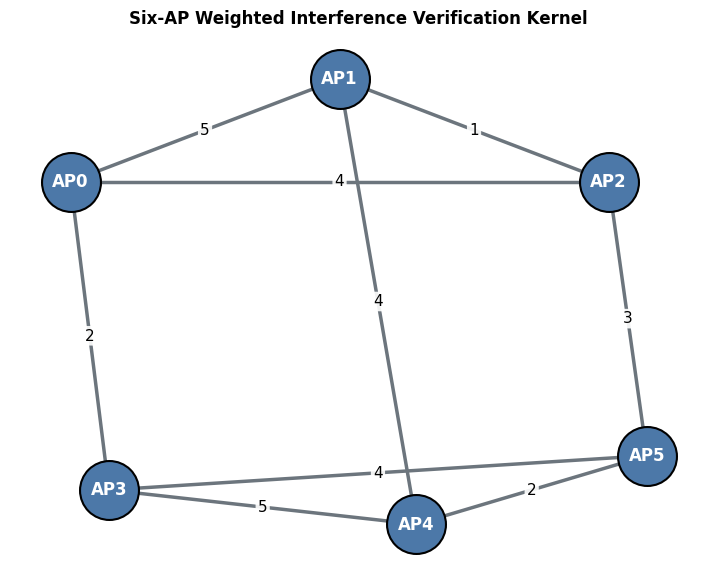

In [4]:
import matplotlib.pyplot as plt

# Fixed drawing positions so all later kernel plots look the same.
positions = {
    "AP0": (-1.4, 0.8),
    "AP1": (0.0, 1.4),
    "AP2": (1.4, 0.8),
    "AP3": (-1.2, -1.0),
    "AP4": (0.4, -1.2),
    "AP5": (1.6, -0.8),
}

# Create labels showing the interference weight on each edge.
edge_labels = {
    (u, v): f"{data['weight']:.0f}"
    for u, v, data in G.edges(data=True)
}

plt.figure(figsize=(9, 7))

# Draw weighted interference connections.
nx.draw_networkx_edges(
    G,
    positions,
    width=2.5,
    edge_color="#6C757D"
)

# Draw AP nodes.
nx.draw_networkx_nodes(
    G,
    positions,
    node_color="#4C78A8",
    node_size=1800,
    edgecolors="black",
    linewidths=1.5
)

# Draw AP names and edge weights.
nx.draw_networkx_labels(
    G,
    positions,
    font_size=12,
    font_weight="bold",
    font_color="white"
)

nx.draw_networkx_edge_labels(
    G,
    positions,
    edge_labels=edge_labels,
    font_size=11,
    rotate=False,
    bbox={
        "boxstyle": "round,pad=0.15",
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.9
    }
)

plt.title("Six-AP Weighted Interference Verification Kernel", fontweight="bold")
plt.axis("off")
plt.show()

In [5]:
# Testing one channel assignment in AP order: AP0, AP1, AP2, AP3, AP4, AP5
candidate_bitstring = "011010"

# Store the chosen channel for each AP
assignment = {
    ap: int(bit)
    for ap, bit in zip(AP_NODES, candidate_bitstring)
}

separated_weight = 0.0
residual_weight = 0.0
edge_results = []

# Check whether each interfering AP pair uses the same or different channel
for ap_u, ap_v, weight in EDGE_LIST:
    separated = assignment[ap_u] != assignment[ap_v]

    if separated:
        separated_weight += weight
    else:
        residual_weight += weight

    edge_results.append([
        ap_u,
        ap_v,
        weight,
        assignment[ap_u],
        assignment[ap_v],
        separated
    ])

# Show the calculation edge by edge.
assignment_df = pd.DataFrame(
    edge_results,
    columns=[
        "AP_u",
        "AP_v",
        "weight",
        "channel_u",
        "channel_v",
        "separated"
    ]
)

print(f"Bitstring: {candidate_bitstring}")
print(f"Separated interference weight: {separated_weight:.1f}")
print(f"Residual interference weight: {residual_weight:.1f}")
print(f"Check: {separated_weight:.1f} + {residual_weight:.1f} = "
      f"{separated_weight + residual_weight:.1f}")

display(assignment_df)

Bitstring: 011010
Separated interference weight: 19.0
Residual interference weight: 11.0
Check: 19.0 + 11.0 = 30.0


,AP_u,AP_v,weight,channel_u,channel_v,separated
0,AP0,AP1,5.0,0,1,True
1,AP0,AP2,4.0,0,1,True
2,AP0,AP3,2.0,0,0,False
3,AP1,AP2,1.0,1,1,False
4,AP1,AP4,4.0,1,1,False
5,AP2,AP5,3.0,1,0,True
6,AP3,AP4,5.0,0,1,True
7,AP3,AP5,4.0,0,0,False
8,AP4,AP5,2.0,1,0,True


### Exhaustively Finding the Real Optimum

In [6]:

# Evaluating every possible 6-bit channel assignment
all_results = []

for bits in product([0, 1], repeat=len(AP_NODES)):
    bitstring = "".join(map(str, bits))

    assignment = {
        ap: bit
        for ap, bit in zip(AP_NODES, bits)
    }

    separated_weight = sum(
        weight
        for ap_u, ap_v, weight in EDGE_LIST
        if assignment[ap_u] != assignment[ap_v]
    )

    residual_weight = sum(
        weight
        for ap_u, ap_v, weight in EDGE_LIST
        if assignment[ap_u] == assignment[ap_v]
    )

    all_results.append({
        "bitstring": bitstring,
        "separated_weight": separated_weight,
        "residual_weight": residual_weight
    })

# Sorting from the largest cut value to the smallest.
enumeration_df = pd.DataFrame(all_results).sort_values(
    by="separated_weight",
    ascending=False
).reset_index(drop=True)

exact_optimum = enumeration_df["separated_weight"].max()

optimal_solutions_df = enumeration_df[enumeration_df["separated_weight"] == exact_optimum].copy()

print(f"Assignments evaluated: {len(enumeration_df)}")
print(f"Exact maximum separated weight: {exact_optimum:.1f}")
print(f"Equivalent minimum energy: {-exact_optimum:.1f}")
print(f"Number of optimal assignments: {len(optimal_solutions_df)}")

display(optimal_solutions_df)
display(enumeration_df.head(10))

Assignments evaluated: 64
Exact maximum separated weight: 27.0
Equivalent minimum energy: -27.0
Number of optimal assignments: 2


,bitstring,separated_weight,residual_weight
0,011100,27.0,3.0
1,100011,27.0,3.0


,bitstring,separated_weight,residual_weight
0,011100,27.0,3.0
1,100011,27.0,3.0
2,011101,22.0,8.0
3,010101,22.0,8.0
4,100010,22.0,8.0
5,101010,22.0,8.0
6,101011,21.0,9.0
7,010100,21.0,9.0
8,001110,20.0,10.0
9,011110,20.0,10.0


### MILP Formulation:

Going to solve the same weighted MaxCut problem using a classical exact solver
- x[AP] is the binary channel assigned to each AP
- y[edge] is 1 when two APs use different channels
- Objective: Maximise weighted separated interference

In [7]:
# MILP model that maximizes separated interference weight
milp_model = pulp.LpProblem(
    "Wireless_Interference_MaxCut",
    pulp.LpMaximize
)

# One binary channel variable for each AP.
x = {
    ap: pulp.LpVariable(
        f"channel_{ap}",
        cat="Binary"
    )
    for ap in AP_NODES
}

# Fix AP0 to channel 0. This removes the equivalent solution with every channel label flipped.
milp_model += x["AP0"] == 0

y = {}

for ap_u, ap_v, weight in EDGE_LIST:
    # y=1 means AP_u and AP_v are assigned different channels
    y[(ap_u, ap_v)] = pulp.LpVariable(
        f"separated_{ap_u}_{ap_v}",
        cat="Binary"
    )

    # These constraints force y to equal |x_u - x_v|
    milp_model += y[(ap_u, ap_v)] >= x[ap_u] - x[ap_v]
    milp_model += y[(ap_u, ap_v)] >= x[ap_v] - x[ap_u]
    milp_model += y[(ap_u, ap_v)] <= x[ap_u] + x[ap_v]
    milp_model += y[(ap_u, ap_v)] <= 2 - x[ap_u] - x[ap_v]

# Maximize the total weight of separated interference edges
milp_model += pulp.lpSum(
    weight * y[(ap_u, ap_v)]
    for ap_u, ap_v, weight in EDGE_LIST
)

print(f"Binary AP variables: {len(x)}")
print(f"Binary edge variables: {len(y)}")
print(f"Total MILP binary variables: {len(x) + len(y)}")
print(f"XOR constraints: {4 * len(y) + 1}")

## 9 edges x 4 XOR constraints = 36; Plus one extra constraint x_AP0 = 0 fixes AP0's channel

## Note that: Fixing AP0 does not remove the real optimum. It only removes the duplicate solution obtained by swapping every channel label

Binary AP variables: 6
Binary edge variables: 9
Total MILP binary variables: 15
XOR constraints: 37


In [8]:
# Start timing the exact classical solve
start_time = perf_counter()

# Use the selected MILP solver
if BACKEND == "highs":
    solver = pulp.HiGHS(
        msg=False,              # Hide detailed solver logs
        threads=1,              # Use one CPU thread for reproducible timing
        gapRel=0.0,             # Require zero relative optimality gap
        random_seed=SEED
    )
else:
    solver = pulp.PULP_CBC_CMD(
        msg=False,
        threads=1,
        gapRel=0.0,             # Require a proven optimum
        options=[f"randomSeed {SEED}"]
    )

milp_model.solve(solver)  ##  Solve the MaxCut MILP model
milp_runtime_seconds = perf_counter() - start_time  # Save total solver runtime.

# Convert the AP channel variables into the project bitstring order: AP0, AP1, AP2, AP3, AP4, AP5
milp_bitstring = "".join(
    str(int(round(x[ap].value())))
    for ap in AP_NODES
)

# Read the maximized separated interference weight
milp_cut = float(pulp.value(milp_model.objective))

print("MILP status:", pulp.LpStatus[milp_model.status])
print("MILP bitstring:", milp_bitstring)
print(f"MILP separated weight: {milp_cut:.1f}")
print(f"MILP energy: {-milp_cut:.1f}")
print(f"MILP runtime: {milp_runtime_seconds:.6f} seconds")

# Confirming that MILP found the exact result from the 64-state enumeration
assert pulp.LpStatus[milp_model.status] == "Optimal"
assert np.isclose(milp_cut, exact_optimum)

print("Validation passed: MILP matches exhaustive enumeration.")

MILP status: Optimal
MILP bitstring: 011100
MILP separated weight: 27.0
MILP energy: -27.0
MILP runtime: 0.091277 seconds
Validation passed: MILP matches exhaustive enumeration.


### QUBO encoding

We convert the same MaxCut objective into a binary quadratic form:

**E_QUBO(x) = x.T @ Q @ x = -C(x)**

For each interference edge (u,v) with weight w_uv:

-w_uv(x_u + x_v - 2 x_u x_v) = -w_uv x_u - w_uv x_v + 2 w_uv x_u x_v

It simply means
 - Every edge subtracts its weight from the diagonal entry of both endpoint APs
 - Every edge adds 2 w_uv to the upper-triangular interaction entry

In [9]:
# Building the upper-triangular QUBO matrix for:
# x.T @ Q @ x = - separated_interference_weight

N = len(AP_NODES)

# Q has one row and column per AP: AP0 to AP5
Q = np.zeros((N, N))

for ap_u, ap_v, weight in EDGE_LIST:
    u = NODE_TO_INDEX[ap_u]
    v = NODE_TO_INDEX[ap_v]

    # Store each quadratic term in the upper triangle
    if u > v:
        u, v = v, u

    # Each edge contributes -w*x_u and -w*x_v.
    Q[u, u] -= weight
    Q[v, v] -= weight

    # Each edge contributes +2*w*x_u*x_v.
    Q[u, v] += 2 * weight

# QUBO matrix with AP labels.
qubo_df = pd.DataFrame(
    Q,
    index=AP_NODES,
    columns=AP_NODES
)

print("QUBO matrix shape:", Q.shape)
display(qubo_df)

QUBO matrix shape: (6, 6)


,AP0,AP1,AP2,AP3,AP4,AP5
AP0,-11.0,10.0,8.0,4.0,0.0,0.0
AP1,0.0,-10.0,2.0,0.0,8.0,0.0
AP2,0.0,0.0,-8.0,0.0,0.0,6.0
AP3,0.0,0.0,0.0,-11.0,10.0,8.0
AP4,0.0,0.0,0.0,0.0,-11.0,4.0
AP5,0.0,0.0,0.0,0.0,0.0,-9.0


### Verifying QUBO against every assignment

x.T @ Q @ x = -C(x)

In [10]:
qubo_results = []

# Checking every possible 6-bit channel assignment.
for bits in product([0, 1], repeat=N):
    bitstring = "".join(map(str, bits))
    x_vector = np.array(bits)

    # Calculate the QUBO energy: x.T @ Q @ x.
    qubo_energy = float(x_vector @ Q @ x_vector)

    # Read the matching classical MaxCut score from enumeration
    classical_cut = enumeration_df.loc[
        enumeration_df["bitstring"] == bitstring,
        "separated_weight"
    ].iloc[0]

    qubo_results.append({
        "bitstring": bitstring,
        "classical_cut": classical_cut,
        "qubo_energy": qubo_energy,
        "energy_difference": qubo_energy + classical_cut
    })

qubo_validation_df = pd.DataFrame(qubo_results).sort_values(
    by="qubo_energy"
).reset_index(drop=True)

# The QUBO minimum must equal negative exact MaxCut optimum
qubo_minimum_energy = qubo_validation_df["qubo_energy"].min()

print(f"QUBO minimum energy: {qubo_minimum_energy:.1f}")
print(f"Equivalent separated weight: {-qubo_minimum_energy:.1f}")

# Every assignment must satisfy QUBO energy = -classical cut.
assert np.allclose(qubo_validation_df["energy_difference"], 0.0)
assert np.isclose(qubo_minimum_energy, -exact_optimum)

print("Validation passed: QUBO energy matches every classical assignment.")

display(qubo_validation_df.head(10))

QUBO minimum energy: -27.0
Equivalent separated weight: 27.0
Validation passed: QUBO energy matches every classical assignment.


,bitstring,classical_cut,qubo_energy,energy_difference
0,011100,27.0,-27.0,0.0
1,100011,27.0,-27.0,0.0
2,011101,22.0,-22.0,0.0
3,010101,22.0,-22.0,0.0
4,100010,22.0,-22.0,0.0
5,101010,22.0,-22.0,0.0
6,101011,21.0,-21.0,0.0
7,010100,21.0,-21.0,0.0
8,001110,20.0,-20.0,0.0
9,011110,20.0,-20.0,0.0


### Converting QUBO to an Ising Hamiltonian

QAOA works with a quantum operator. Not the QUBO matrix directly. We use:

x_i = ( 1 - z_i) / 2 ; z_i ∈ {-1,+1}

For this MaxCut problem, the minimised Hamiltonian is:

H_E = ∑ w_uv (Z_u Z_v - I ) / 2; where (u,v) ∈ E

For every bitstring :
⟨x | H_E | x⟩ = E_QUBO(x) = -C(x)


In [11]:
# Building the Ising cost Hamiltonian for the minimized energy
# H = sum w_uv * (Z_u Z_v - I) / 2

ising_terms = []

for ap_u, ap_v, weight in EDGE_LIST:
    u = NODE_TO_INDEX[ap_u]
    v = NODE_TO_INDEX[ap_v]

    # The ZZ term contributes +w/2 when APs match and -w/2 when they differ
    ising_terms.append(("ZZ", [u, v], weight / 2))

    # The identity term shifts the energy so it equals -MaxCut value
    ising_terms.append(("I", [0], -weight / 2))

# Create a sparse 6-qubit Pauli operator.
cost_hamiltonian = SparsePauliOp.from_sparse_list(
    ising_terms,
    num_qubits=N
)

print("Number of qubits:", cost_hamiltonian.num_qubits)
print("Number of Pauli terms:", len(cost_hamiltonian))
print(cost_hamiltonian)

Number of qubits: 6
Number of Pauli terms: 18
SparsePauliOp(['IIIIZZ', 'IIIIII', 'IIIZIZ', 'IIIIII', 'IIZIIZ', 'IIIIII', 'IIIZZI', 'IIIIII', 'IZIIZI', 'IIIIII', 'ZIIZII', 'IIIIII', 'IZZIII', 'IIIIII', 'ZIZIII', 'IIIIII', 'ZZIIII', 'IIIIII'],
              coeffs=[ 2.5+0.j, -2.5+0.j,  2. +0.j, -2. +0.j,  1. +0.j, -1. +0.j,  0.5+0.j,
 -0.5+0.j,  2. +0.j, -2. +0.j,  1.5+0.j, -1.5+0.j,  2.5+0.j, -2.5+0.j,
  2. +0.j, -2. +0.j,  1. +0.j, -1. +0.j])


### Verifying the Ising Energy for all 64 assignments

In [12]:
ising_results = []

# Checking every possible binary AP-channel assignment
for bits in product([0, 1], repeat=N):
    bitstring = "".join(map(str, bits))

    # Convert channel bits to Ising spin values:
    # channel 0 -> z = +1, channel 1 -> z = -1.
    spins = 1 - 2 * np.array(bits)

    ising_energy = 0.0

    # Evaluate H = sum w_uv * (z_u*z_v - 1) / 2
    for ap_u, ap_v, weight in EDGE_LIST:
        u = NODE_TO_INDEX[ap_u]
        v = NODE_TO_INDEX[ap_v]

        ising_energy += weight * (spins[u] * spins[v] - 1) / 2

    # Read the matching QUBO energy from the previous validation table
    qubo_energy = qubo_validation_df.loc[
        qubo_validation_df["bitstring"] == bitstring,
        "qubo_energy"
    ].iloc[0]

    ising_results.append({
        "bitstring": bitstring,
        "qubo_energy": qubo_energy,
        "ising_energy": ising_energy,
        "energy_difference": ising_energy - qubo_energy
    })

ising_validation_df = pd.DataFrame(ising_results).sort_values(
    by="ising_energy"
).reset_index(drop=True)

ising_ground_energy = ising_validation_df["ising_energy"].min()

print(f"Ising ground-state energy: {ising_ground_energy:.1f}")
print(f"Matching QUBO minimum energy: {qubo_minimum_energy:.1f}")

# Every assignment must have identical QUBO and Ising energy
assert np.allclose(ising_validation_df["energy_difference"], 0.0)
assert np.isclose(ising_ground_energy, qubo_minimum_energy)

print("Validation passed: Ising energy matches QUBO energy.")

display(ising_validation_df.head(5))

Ising ground-state energy: -27.0
Matching QUBO minimum energy: -27.0
Validation passed: Ising energy matches QUBO energy.


,bitstring,qubo_energy,ising_energy,energy_difference
0,011100,-27.0,-27.0,0.0
1,100011,-27.0,-27.0,0.0
2,011101,-22.0,-22.0,0.0
3,010101,-22.0,-22.0,0.0
4,100010,-22.0,-22.0,0.0


### Checking the actual Qiskit Hamiltonian
Just checking the real Qiskit operator tht QAOA will use

In [13]:
qiskit_ising_results = []

# Evaluate the Qiskit Hamiltonian on every computational-basis assignment
for bits in product([0, 1], repeat=N):
    bitstring = "".join(map(str, bits))

    # Qiskit basis index uses qubit 0 as the least-significant bit
    basis_index = sum(
        bit << qubit
        for qubit, bit in enumerate(bits)
    )

    # Create the basis state matching AP0, AP1, ..., AP5
    basis_state = Statevector.from_int(
        basis_index,
        2 ** N
    )

    # Evaluate the actual SparsePauliOp expectation value
    qiskit_energy = float(
        np.real(
            basis_state.expectation_value(cost_hamiltonian)
        )
    )

    manual_ising_energy = ising_validation_df.loc[
        ising_validation_df["bitstring"] == bitstring,
        "ising_energy"
    ].iloc[0]

    qiskit_ising_results.append({
        "bitstring": bitstring,
        "manual_ising_energy": manual_ising_energy,
        "qiskit_ising_energy": qiskit_energy,
        "energy_difference": qiskit_energy - manual_ising_energy
    })

qiskit_ising_validation_df = pd.DataFrame(
    qiskit_ising_results
).sort_values(
    by="qiskit_ising_energy"
).reset_index(drop=True)

print(
    "Qiskit Hamiltonian ground energy:",
    qiskit_ising_validation_df["qiskit_ising_energy"].min()
)

# Confirming whether Qiskit's actual operator matches the manual Ising energy for all states
assert np.allclose(
    qiskit_ising_validation_df["energy_difference"],
    0.0
)

print("Validation passed: Qiskit SparsePauliOp matches Ising energy.")

display(qiskit_ising_validation_df.head(10))

Qiskit Hamiltonian ground energy: -27.0
Validation passed: Qiskit SparsePauliOp matches Ising energy.


,bitstring,manual_ising_energy,qiskit_ising_energy,energy_difference
0,011100,-27.0,-27.0,0.0
1,100011,-27.0,-27.0,0.0
2,011101,-22.0,-22.0,0.0
3,010101,-22.0,-22.0,0.0
4,100010,-22.0,-22.0,0.0
5,101010,-22.0,-22.0,0.0
6,101011,-21.0,-21.0,0.0
7,010100,-21.0,-21.0,0.0
8,001110,-20.0,-20.0,0.0
9,011110,-20.0,-20.0,0.0


### ALL VERIFICATIONS DONE

 **Enumeration = MILP = QUBO = manual Ising = Qiskit Hamiltonian**

C* = 27; E* = -27

### Building the p = 1 QAOA Circuit

Just creating a six-qubit circuit with two adjustable parameters:

- γ controls the cost layer
- β controls the mixer layer

In [14]:
# QAOA depth p=1 means one cost layer and one mixer layer
P = 1

# p=1 has one cost angle gamma and one mixer angle beta
gamma = ParameterVector("gamma", P)
beta = ParameterVector("beta", P)

# Create one qubit for each AP
qaoa_circuit = QuantumCircuit(N)

# Obviously, we start from an equal superposition of all 64 channel assignments
qaoa_circuit.h(range(N))

# Add one weighted ZZ cost interaction for every interference edge
for ap_u, ap_v, weight in EDGE_LIST:
    u = NODE_TO_INDEX[ap_u]
    v = NODE_TO_INDEX[ap_v]

    # CX-RZ-CX implements the weighted ZZ interaction
    qaoa_circuit.cx(u, v)
    qaoa_circuit.rz(gamma[0] * weight, v)
    qaoa_circuit.cx(u, v)

# Add one mixer rotation to every AP qubit
for qubit in range(N):
    qaoa_circuit.rx(2 * beta[0], qubit)

# Decomposing the circuit so the individual QAOA gates are visible
qaoa_p1_draw = qaoa_circuit.decompose(reps=3)

print("Qubits:", qaoa_circuit.num_qubits)
print("Parameters:", list(qaoa_circuit.parameters))
print("CX gates:", qaoa_circuit.count_ops().get("cx", 0))
print("Circuit depth:", qaoa_circuit.depth())

print(qaoa_p1_draw.draw("text", fold=120))

Qubits: 6
Parameters: [ParameterVectorElement(beta[0]), ParameterVectorElement(gamma[0])]
CX gates: 18
Circuit depth: 23
global phase: (-15)*gamma[0]
     ┌────────────┐                                                                                                  »
q_0: ┤ U(π/2,0,π) ├──■─────────────────────────■────■─────────────────────────■─────────■────────────────────────────»
     ├────────────┤┌─┴─┐┌───────────────────┐┌─┴─┐  │                         │         │                            »
q_1: ┤ U(π/2,0,π) ├┤ X ├┤ U(0,0,5*gamma[0]) ├┤ X ├──┼─────────────────────────┼────■────┼─────────────────────────■──»
     ├────────────┤└───┘└───────────────────┘└───┘┌─┴─┐┌───────────────────┐┌─┴─┐┌─┴─┐  │   ┌─────────────────┐ ┌─┴─┐»
q_2: ┤ U(π/2,0,π) ├───────────────────────────────┤ X ├┤ U(0,0,4*gamma[0]) ├┤ X ├┤ X ├──┼───┤ U(0,0,gamma[0]) ├─┤ X ├»
     ├────────────┤                               └───┘└───────────────────┘└───┘└───┘┌─┴─┐┌┴─────────────────┴┐└───┘»
q_3: ┤ U(π/2,0,π)

In [15]:
# Use test values only to check that the p=1 QAOA circuit runs
# COBYLA will optimize gamma and beta later
test_gamma = 0.30
test_beta = 0.20

# Replace the symbolic QAOA parameters with numerical values
test_circuit = qaoa_circuit.assign_parameters({
    gamma[0]: test_gamma,
    beta[0]: test_beta
})

# Simulate the exact quantum state for this parameter setting
test_statevector = Statevector.from_instruction(test_circuit)

# Calculate the expected Ising energy of the output state
test_energy = float(
    np.real(
        test_statevector.expectation_value(cost_hamiltonian)
    )
)

print(f"Test gamma: {test_gamma:.3f}")
print(f"Test beta: {test_beta:.3f}")
print(f"Expected Ising energy: {test_energy:.6f}")
print(f"Expected separated weight: {-test_energy:.6f}")
print(f"Exact classical optimum: {exact_optimum:.1f}")

Test gamma: 0.300
Test beta: 0.200
Expected Ising energy: -12.367054
Expected separated weight: 12.367054
Exact classical optimum: 27.0


### COBYLA

Constrained Optimisation BY Linear Approximation. It is a normal classical algorithm that  searches for better QAOA angles.

For p = 1, it searches over only [γ,β]

Procedure:
- Try gamma, beta
- Run QAOA circuit
- Measure exact expected energy
- Try improved gamma, beta
- Repeat

E(γ,β)=⟨ψ(γ,β) | H_E | ψ(γ,β)⟩

and tell it to minimiswe that energy

In [16]:
# Return the exact expected Ising energy for a given [gamma, beta]
# COBYLA will minimize this value
def qaoa_energy(theta):
    gamma_value, beta_value = theta

    # Bind numerical angles to the p=1 circuit
    bound_circuit = qaoa_circuit.assign_parameters({
        gamma[0]: gamma_value,
        beta[0]: beta_value
    })

    # Simulate the complete statevector and evaluate <H>
    statevector = Statevector.from_instruction(bound_circuit)

    return float(
        np.real(
            statevector.expectation_value(cost_hamiltonian)
        )
    )


# Start from the same test angles used in the previous cell
initial_angles = np.array([0.30, 0.20])

# COBYLA changes gamma and beta to minimize expected Ising energy
start_time = perf_counter()

p1_result = minimize(
    fun=qaoa_energy,
    x0=initial_angles,
    method="COBYLA",
    options={
        "maxiter": 100,  # Maximum number of energy evaluations.
        "rhobeg": 0.5,   # Initial search-step size.
        "tol": 1e-4      # Stop when the local search region becomes small.
    }
)

p1_runtime_seconds = perf_counter() - start_time

# Extract the best p=1 angles found by COBYLA
p1_gamma, p1_beta = p1_result.x
p1_energy = float(p1_result.fun)
p1_expected_cut = -p1_energy

print("COBYLA success:", p1_result.success)
print("COBYLA message:", p1_result.message)
print(f"Optimized gamma: {p1_gamma:.6f}")
print(f"Optimized beta: {p1_beta:.6f}")
print(f"Best expected Ising energy: {p1_energy:.6f}")
print(f"Best expected separated weight: {p1_expected_cut:.6f}")
print(f"Exact classical optimum: {exact_optimum:.1f}")
print(f"COBYLA evaluations: {p1_result.nfev}")
print(f"Optimization runtime: {p1_runtime_seconds:.3f} seconds")

COBYLA success: True
COBYLA message: Return from COBYLA because the trust region radius reaches its lower bound.
Optimized gamma: 0.783822
Optimized beta: 1.178082
Best expected Ising energy: -16.914435
Best expected separated weight: 16.914435
Exact classical optimum: 27.0
COBYLA evaluations: 47
Optimization runtime: 0.781 seconds


### p - 1 multistart

In [17]:
# Testing several initial angle pairs because COBYLA is a local optimizer
# Just checking whether one starting point gave an unusually poor local result

rng = np.random.default_rng(SEED)

p1_multistart_results = []

for start_id in range(8):
    # Draw one different starting point for gamma and beta
    initial_angles = rng.uniform(
        low=-np.pi,
        high=np.pi,
        size=2
    )

    start_time = perf_counter()

    result = minimize(
        fun=qaoa_energy,
        x0=initial_angles,
        method="COBYLA",
        options={
            "maxiter": 100,
            "rhobeg": 0.5,
            "tol": 1e-4
        }
    )

    runtime_seconds = perf_counter() - start_time

    p1_multistart_results.append({
        "start_id": start_id,
        "initial_gamma": initial_angles[0],
        "initial_beta": initial_angles[1],
        "final_gamma": result.x[0],
        "final_beta": result.x[1],
        "expected_energy": result.fun,
        "expected_cut": -result.fun,
        "evaluations": result.nfev,
        "success": result.success,
        "runtime_seconds": runtime_seconds
    })

p1_multistart_df = pd.DataFrame(
    p1_multistart_results
).sort_values(
    by="expected_energy",
    ascending=True
).reset_index(drop=True)

# Select the lowest-energy p=1 run for later sampling
best_p1 = p1_multistart_df.iloc[0]

print(f"Best p=1 expected energy: {best_p1['expected_energy']:.6f}")
print(f"Best p=1 expected cut: {best_p1['expected_cut']:.6f}")
print(f"Exact classical optimum: {exact_optimum:.1f}")
print(f"Best gamma: {best_p1['final_gamma']:.6f}")
print(f"Best beta: {best_p1['final_beta']:.6f}")

display(p1_multistart_df)

Best p=1 expected energy: -20.614142
Best p=1 expected cut: 20.614142
Exact classical optimum: 27.0
Best gamma: 0.165322
Best beta: -1.931715


,start_id,initial_gamma,initial_beta,final_gamma,final_beta,expected_energy,expected_cut,evaluations,success,runtime_seconds
0,7,-0.355539,-1.713810,0.165322,-1.931715,-20.614142,20.614142,41,True,1.073952
1,0,1.721317,-0.384038,1.600040,0.410762,-18.132745,18.132745,58,True,0.648040
2,3,1.640789,1.797395,1.600028,1.981356,-18.132745,18.132745,53,True,0.418174
3,2,-2.549859,2.988423,-1.600103,2.730588,-18.132742,18.132742,58,True,0.741067
4,6,0.903931,2.027971,1.065988,2.343346,-16.911236,16.911236,100,False,1.499431
5,4,-2.336631,-0.311734,-2.452938,0.400980,-16.826215,16.826215,53,True,0.545752
6,5,-0.811800,2.681444,-1.161348,3.650836,-16.780154,16.780154,100,False,1.188032
7,1,2.253137,1.240100,2.697923,1.977792,-15.735453,15.735453,86,True,1.332307


 Cobyla  is initialisation sensitive. It is normal for a non-convex variational quantum optimisation landscape

### Exact Ideal Probability Distribution

In [18]:
# Use the best p=1 angles found by the multistart search
best_p1_gamma = float(best_p1["final_gamma"])
best_p1_beta = float(best_p1["final_beta"])

# Bind the best angles to the p=1 circuit
best_p1_circuit = qaoa_circuit.assign_parameters({
    gamma[0]: best_p1_gamma,
    beta[0]: best_p1_beta
})

# Get the exact statevector probabilities for all 64 assignments
best_p1_statevector = Statevector.from_instruction(best_p1_circuit)
probabilities = best_p1_statevector.probabilities()

distribution_rows = []

for bits in product([0, 1], repeat=N):
    bitstring = "".join(map(str, bits))

    # Qiskit statevector index uses AP0 as the least-significant bit
    basis_index = sum(
        bit << qubit
        for qubit, bit in enumerate(bits)
    )

    cut_value = enumeration_df.loc[
        enumeration_df["bitstring"] == bitstring,
        "separated_weight"
    ].iloc[0]

    distribution_rows.append({
        "bitstring": bitstring,
        "probability": probabilities[basis_index],
        "separated_weight": cut_value,
        "is_optimal": bitstring in {"011100", "100011"}
    })

p1_distribution_df = pd.DataFrame(
    distribution_rows
).sort_values(
    by="probability",
    ascending=False
).reset_index(drop=True)

p1_expected_cut = float(
    (p1_distribution_df["probability"] *
     p1_distribution_df["separated_weight"]).sum()
)

p1_optimum_probability = float(
    p1_distribution_df.loc[
        p1_distribution_df["is_optimal"],
        "probability"
    ].sum()
)

print(f"p=1 expected cut from probabilities: {p1_expected_cut:.6f}")
print(f"Best p=1 optimizer result: {best_p1['expected_cut']:.6f}")
print(f"Total probability of exact optima: {p1_optimum_probability:.4%}")
print(f"Uniform-random optimum probability: {2 / (2 ** N):.4%}")

display(p1_distribution_df.head(10))

p=1 expected cut from probabilities: 20.614142
Best p=1 optimizer result: 20.614142
Total probability of exact optima: 21.1674%
Uniform-random optimum probability: 3.1250%


,bitstring,probability,separated_weight,is_optimal
0,011100,0.105837,27.0,True
1,100011,0.105837,27.0,True
2,101010,0.046117,22.0,False
3,010101,0.046117,22.0,False
4,001110,0.037914,20.0,False
5,110001,0.037914,20.0,False
6,100101,0.036609,19.0,False
7,011010,0.036609,19.0,False
8,010011,0.030125,18.0,False
9,101100,0.030125,18.0,False


#### Observation

Optimized depth-1 QAOA concentrated **21.17% ideal-state probability** on the two globally optimal assignments, compared with a 3.125% (2/64) uniform-random baseline, while achieving expected cut 20.61 versus exact optimum 27.

### Finite shot p=1 measurement

Use the optimized p=1 circuit and run 4,096 ideal shots

In [19]:
# Copying the optimized p=1 circuit and adding final measurements
p1_measured_circuit = best_p1_circuit.copy()
p1_measured_circuit.measure_all()

SHOTS = 4096  # Number of repeated circuit measurements

# Run ideal finite-shot simulation with a fixed random seed
ideal_simulator = AerSimulator(
    method="statevector",
    seed_simulator=SEED
)

raw_counts = ideal_simulator.run(
    p1_measured_circuit,
    shots=SHOTS
).result().get_counts()

# Qiskit returns bitstrings in q5...q0 order
# Reversing them to recover our project order: AP0...AP5.
p1_counts = {
    qiskit_string[::-1]: count
    for qiskit_string, count in raw_counts.items()
}

shot_rows = []

# Score every measured assignment using the exact classical lookup table
for bitstring, count in p1_counts.items():
    cut = enumeration_df.loc[
        enumeration_df["bitstring"] == bitstring,
        "separated_weight"
    ].iloc[0]

    shot_rows.append({
        "bitstring": bitstring,
        "count": count,
        "probability": count / SHOTS,
        "cut": cut,
        "is_optimal": bitstring in {"011100", "100011"}
    })

# Sort from the most frequently measured assignment
p1_shots_df = pd.DataFrame(shot_rows).sort_values(
    by="count",
    ascending=False
).reset_index(drop=True)

# Calculate average cut quality across all 4,096 sampled measurements
p1_shot_expected_cut = (
    p1_shots_df["probability"] * p1_shots_df["cut"]
).sum()

# Add the sampled probabilities of both globally optimal assignments
p1_shot_optimum_probability = p1_shots_df.loc[
    p1_shots_df["is_optimal"],
    "probability"
].sum()

print(f"Finite-shot expected cut: {p1_shot_expected_cut:.6f}")
print(f"Exact statevector expected cut: {best_p1['expected_cut']:.6f}")
print(f"Finite-shot optimum probability: {p1_shot_optimum_probability:.4%}")
print(f"Exact optimum probability: {p1_optimum_probability:.4%}")
print(f"Shots: {SHOTS}")

display(p1_shots_df.head(10))

Finite-shot expected cut: 20.609863
Exact statevector expected cut: 20.614142
Finite-shot optimum probability: 21.1914%
Exact optimum probability: 21.1674%
Shots: 4096


,bitstring,count,probability,cut,is_optimal
0,100011,440,0.107422,27.0,True
1,011100,428,0.104492,27.0,True
2,010101,182,0.044434,22.0,False
3,001110,178,0.043457,20.0,False
4,101010,176,0.042969,22.0,False
5,100101,165,0.040283,19.0,False
6,011010,154,0.037598,19.0,False
7,110001,150,0.036621,20.0,False
8,011101,134,0.032715,22.0,False
9,101100,132,0.032227,18.0,False


### Building the p = 2 QAOA circuit

p = 2 has two cost layers and two mixer layers: (γ_1,β_1,γ_2,β_2)

 This should give the circuit more flexibility, but also doubles the number of weighted edge interactions

In [20]:
# QAOA depth p=2 means two cost layers and two mixer layers
P2 = 2

# p=2 has two gamma angles and two beta angles
gamma_p2 = ParameterVector("gamma_p2", P2)
beta_p2 = ParameterVector("beta_p2", P2)

# Create one qubit for each AP
qaoa_p2 = QuantumCircuit(N)

# Same... Start from an equal superposition of all 64 channel assignments
qaoa_p2.h(range(N))

# Add two QAOA layers
for layer in range(P2):

    # Add the weighted MaxCut cost layer
    for ap_u, ap_v, weight in EDGE_LIST:
        u = NODE_TO_INDEX[ap_u]
        v = NODE_TO_INDEX[ap_v]

        # CX-RZ-CX implements one weighted ZZ cost interaction
        qaoa_p2.cx(u, v)
        qaoa_p2.rz(gamma_p2[layer] * weight, v)
        qaoa_p2.cx(u, v)

    # Add the mixer layer.
    for qubit in range(N):
        qaoa_p2.rx(2 * beta_p2[layer], qubit)


qaoa_p2_draw = qaoa_p2.decompose(reps=3)

print("Qubits:", qaoa_p2.num_qubits)
print("Parameters:", list(qaoa_p2.parameters))
print("CX gates:", qaoa_p2.count_ops().get("cx", 0))
print("Circuit depth:", qaoa_p2.depth())

print(qaoa_p2_draw.draw("text", fold=120))

Qubits: 6
Parameters: [ParameterVectorElement(beta_p2[0]), ParameterVectorElement(beta_p2[1]), ParameterVectorElement(gamma_p2[0]), ParameterVectorElement(gamma_p2[1])]
CX gates: 36
Circuit depth: 36
global phase: (-15)*gamma_p2[0] - 2.5*gamma_p2[1] - 2*gamma_p2[1] - 1*gamma_p2[1] - 0.5*gamma_p2[1] - 2*gamma_p2[1] - 1.5*gamma_p2[1] - 2.5*gamma_p2[1] - 2*gamma_p2[1] - 1*gamma_p2[1]
     ┌────────────┐                                                                              »
q_0: ┤ U(π/2,0,π) ├──■────────────────────────────■────■────────────────────────────■─────────■──»
     ├────────────┤┌─┴─┐┌──────────────────────┐┌─┴─┐  │                            │         │  »
q_1: ┤ U(π/2,0,π) ├┤ X ├┤ U(0,0,5*gamma_p2[0]) ├┤ X ├──┼────────────────────────────┼────■────┼──»
     ├────────────┤└───┘└──────────────────────┘└───┘┌─┴─┐┌──────────────────────┐┌─┴─┐┌─┴─┐  │  »
q_2: ┤ U(π/2,0,π) ├──────────────────────────────────┤ X ├┤ U(0,0,4*gamma_p2[0]) ├┤ X ├┤ X ├──┼──»
     ├────────────┤   

### Optimize p=2 with multistart COBYLA

In [21]:
# Return expected Ising energy for p=2 angles
# [gamma_1, beta_1, gamma_2, beta_2].

def qaoa_p2_energy(theta):
    bound_circuit = qaoa_p2.assign_parameters({
        gamma_p2[0]: theta[0],
        beta_p2[0]: theta[1],
        gamma_p2[1]: theta[2],
        beta_p2[1]: theta[3]
    })

    statevector = Statevector.from_instruction(bound_circuit)

    return float(
        np.real(
            statevector.expectation_value(cost_hamiltonian)
        )
    )


# Use several starts because QAOA's parameter landscape is non-convex
rng = np.random.default_rng(SEED)

p2_multistart_results = []

for start_id in range(8):
    initial_angles = rng.uniform(
        low=-np.pi,
        high=np.pi,
        size=4
    )

    start_time = perf_counter()

    result = minimize(
        fun=qaoa_p2_energy,
        x0=initial_angles,
        method="COBYLA",
        options={
            "maxiter": 150,
            "rhobeg": 0.5,
            "tol": 1e-4
        }
    )

    runtime_seconds = perf_counter() - start_time

    p2_multistart_results.append({
        "start_id": start_id,
        "initial_gamma_1": initial_angles[0],
        "initial_beta_1": initial_angles[1],
        "initial_gamma_2": initial_angles[2],
        "initial_beta_2": initial_angles[3],
        "final_gamma_1": result.x[0],
        "final_beta_1": result.x[1],
        "final_gamma_2": result.x[2],
        "final_beta_2": result.x[3],
        "expected_energy": result.fun,
        "expected_cut": -result.fun,
        "evaluations": result.nfev,
        "success": result.success,
        "runtime_seconds": runtime_seconds
    })

p2_multistart_df = pd.DataFrame(
    p2_multistart_results
).sort_values(
    by="expected_energy",
    ascending=True
).reset_index(drop=True)

best_p2 = p2_multistart_df.iloc[0]

print(f"Best p=2 expected energy: {best_p2['expected_energy']:.6f}")
print(f"Best p=2 expected cut: {best_p2['expected_cut']:.6f}")
print(f"Exact classical optimum: {exact_optimum:.1f}")

display(p2_multistart_df)

Best p=2 expected energy: -20.805679
Best p=2 expected cut: 20.805679
Exact classical optimum: 27.0


,start_id,initial_gamma_1,initial_beta_1,initial_gamma_2,initial_beta_2,final_gamma_1,final_beta_1,final_gamma_2,final_beta_2,expected_energy,expected_cut,evaluations,success,runtime_seconds
0,3,0.903931,2.027971,-0.355539,-1.713810,0.162852,2.747646,0.591939,-1.480789,-20.805679,20.805679,113,True,0.711244
1,6,1.749135,-1.918642,-0.209098,-2.866365,1.782913,-1.826539,-0.201651,-2.728145,-18.668048,18.668048,150,False,0.937865
2,7,-2.172163,1.150130,1.537886,2.937450,-2.079902,0.789310,1.458242,2.583990,-18.649787,18.649787,150,False,0.929257
3,0,1.721317,-0.384038,2.253137,1.240100,1.616662,0.401008,2.152026,1.745707,-18.509179,18.509179,150,False,1.178484
4,5,1.621613,-0.914040,2.957483,2.470053,1.852914,-0.394209,3.234925,1.905974,-18.447536,18.447536,150,False,0.927011
5,2,-2.336631,-0.311734,-0.811800,2.681444,-2.216152,-0.257258,-1.025341,2.785827,-18.110659,18.110659,145,True,0.943936
6,1,-2.549859,2.988423,1.640789,1.797395,-2.433064,3.402206,1.649947,1.859791,-17.459282,17.459282,150,False,0.920672
7,4,0.342966,-2.740617,2.058567,0.827272,0.636904,-2.326681,1.865471,1.018150,-17.439763,17.439763,150,False,0.921059


### p=1 informed p=2 warm start

In [22]:
# Use the best p=1 angles to initialize p=2
# The second layer starts at zero, so this starts from the known p=1 solution

warm_start_angles = np.array([
    best_p1_gamma,  # gamma_1 = best p=1 gamma
    best_p1_beta,   # beta_1 = best p=1 beta
    0.0,            # gamma_2 = no second cost layer at the start
    0.0             # beta_2 = no second mixer layer at the start
])

start_time = perf_counter()

p2_warm_result = minimize(
    fun=qaoa_p2_energy,
    x0=warm_start_angles,
    method="COBYLA",
    options={
        "maxiter": 250,  # Give the four-angle search a modest extra budget
        "rhobeg": 0.3,
        "tol": 1e-4
    }
)

p2_warm_runtime_seconds = perf_counter() - start_time

p2_warm_expected_cut = -float(p2_warm_result.fun)

print("COBYLA success:", p2_warm_result.success)
print("COBYLA message:", p2_warm_result.message)
print(f"Warm-start p=2 expected energy: {p2_warm_result.fun:.6f}")
print(f"Warm-start p=2 expected cut: {p2_warm_expected_cut:.6f}")
print(f"Best random-start p=2 cut: {best_p2['expected_cut']:.6f}")
print(f"Best p=1 cut: {best_p1['expected_cut']:.6f}")
print(f"Warm-start runtime: {p2_warm_runtime_seconds:.3f} seconds")

print("\nOptimized p=2 parameters:")
print(f"gamma_1: {p2_warm_result.x[0]:.6f}")
print(f"beta_1:  {p2_warm_result.x[1]:.6f}")
print(f"gamma_2: {p2_warm_result.x[2]:.6f}")
print(f"beta_2:  {p2_warm_result.x[3]:.6f}")

COBYLA success: False
COBYLA message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
Warm-start p=2 expected energy: -21.384895
Warm-start p=2 expected cut: 21.384895
Best random-start p=2 cut: 20.805679
Best p=1 cut: 20.614142
Warm-start runtime: 1.569 seconds

Optimized p=2 parameters:
gamma_1: 0.124409
beta_1:  -2.205337
gamma_2: -0.075101
beta_2:  0.268653


#### Observation

A p=1-informed p=2 warm start achieved the best observed ideal expected cut, 21.385, within the fixed 250-evaluation budget; COBYLA reached the evaluation budget before its local convergence condition.



In [23]:
# Keep the best observed p=2 parameters from the p=1-informed warm start
best_p2_gamma_1 = float(p2_warm_result.x[0])
best_p2_beta_1 = float(p2_warm_result.x[1])
best_p2_gamma_2 = float(p2_warm_result.x[2])
best_p2_beta_2 = float(p2_warm_result.x[3])

# Bind the selected p=2 parameters to the circuit
best_p2_circuit = qaoa_p2.assign_parameters({
    gamma_p2[0]: best_p2_gamma_1,
    beta_p2[0]: best_p2_beta_1,
    gamma_p2[1]: best_p2_gamma_2,
    beta_p2[1]: best_p2_beta_2
})

# Add final measurements for finite-shot simulation
p2_measured_circuit = best_p2_circuit.copy()
p2_measured_circuit.measure_all()

# Run the same ideal 4,096-shot experiment used for p=1
p2_raw_counts = ideal_simulator.run(
    p2_measured_circuit,
    shots=SHOTS
).result().get_counts()

# Reverse Qiskit q5...q0 strings into project order AP0...AP5
p2_counts = {
    qiskit_string[::-1]: count
    for qiskit_string, count in p2_raw_counts.items()
}

p2_shot_rows = []

for bitstring, count in p2_counts.items():
    cut = enumeration_df.loc[
        enumeration_df["bitstring"] == bitstring,
        "separated_weight"
    ].iloc[0]

    p2_shot_rows.append({
        "bitstring": bitstring,
        "count": count,
        "probability": count / SHOTS,
        "cut": cut,
        "is_optimal": bitstring in {"011100", "100011"}
    })

p2_shots_df = pd.DataFrame(p2_shot_rows).sort_values(
    by="count",
    ascending=False
).reset_index(drop=True)

p2_shot_expected_cut = (
    p2_shots_df["probability"] * p2_shots_df["cut"]
).sum()

p2_shot_optimum_probability = p2_shots_df.loc[
    p2_shots_df["is_optimal"],
    "probability"
].sum()

print(f"p=2 finite-shot expected cut: {p2_shot_expected_cut:.6f}")
print(f"p=2 statevector expected cut: {p2_warm_expected_cut:.6f}")
print(f"p=2 finite-shot optimum probability: {p2_shot_optimum_probability:.4%}")
print(f"p=1 finite-shot optimum probability: {p1_shot_optimum_probability:.4%}")
print(f"Shots: {SHOTS}")

display(p2_shots_df.head(10))

p=2 finite-shot expected cut: 21.378174
p=2 statevector expected cut: 21.384895
p=2 finite-shot optimum probability: 28.6377%
p=1 finite-shot optimum probability: 21.1914%
Shots: 4096


,bitstring,count,probability,cut,is_optimal
0,100011,598,0.145996,27.0,True
1,011100,575,0.140381,27.0,True
2,010101,220,0.053711,22.0,False
3,101010,204,0.049805,22.0,False
4,001110,178,0.043457,20.0,False
5,110001,162,0.039551,20.0,False
6,100101,152,0.037109,19.0,False
7,011010,144,0.035156,19.0,False
8,011001,128,0.031250,19.0,False
9,011101,117,0.028564,22.0,False


### IDEAL P=1 VS P=2 Comparison

Under ideal simulation, the selected p=2 circuit improves on p=1:
E[C]p=1,shots = 20.609863,
E[C]p=2,shots = =21.378174

and the probability of measuring either exact optimum **increases from 21.1914% to 28.6377%**

It is the expected ideal trade-off, the deeper circuit has more expressive parameters and shifts more probability onto optimal solutions

In [24]:
# Comparing optimized ideal QAOA at p=1 and p=2

ideal_qaoa_comparison = pd.DataFrame([
    {
        "setting": "p=1 ideal",
        "expected_cut_statevector": best_p1["expected_cut"],
        "expected_cut_4096_shots": p1_shot_expected_cut,
        "optimum_probability_4096_shots": p1_shot_optimum_probability,
        "cx_gates": qaoa_circuit.count_ops().get("cx", 0),
        "circuit_depth": qaoa_circuit.depth()
    },
    {
        "setting": "p=2 ideal",
        "expected_cut_statevector": p2_warm_expected_cut,
        "expected_cut_4096_shots": p2_shot_expected_cut,
        "optimum_probability_4096_shots": p2_shot_optimum_probability,
        "cx_gates": qaoa_p2.count_ops().get("cx", 0),
        "circuit_depth": qaoa_p2.depth()
    }
])

display(ideal_qaoa_comparison)

,setting,expected_cut_statevector,expected_cut_4096_shots,optimum_probability_4096_shots,cx_gates,circuit_depth
0,p=1 ideal,20.614142,20.609863,0.211914,18,23
1,p=2 ideal,21.384895,21.378174,0.286377,36,36


### Creating the noise model

- 1% two-qubit CX depolarizing-channel parameter
- 1.5% symmetric readout bit-flip error
- Not claiming any particular IBM device

In [25]:
# Defining a simple NISQ-style noise model.
CX_ERROR = 0.01        # Depolarizing-channel parameter applied after every CX gate
READOUT_ERROR = 0.015  # Probability that each measured bit is flipped

noise_model = NoiseModel()

# Add the same two-qubit depolarizing error after every CX gate
cx_noise = depolarizing_error(
    CX_ERROR,
    2
)

noise_model.add_all_qubit_quantum_error(
    cx_noise,
    ["cx"]
)

# A true 0 is read as 1 with probability 1.5%, and vice versa
readout_noise = ReadoutError([
    [1 - READOUT_ERROR, READOUT_ERROR],
    [READOUT_ERROR, 1 - READOUT_ERROR]
])

noise_model.add_all_qubit_readout_error(
    readout_noise
)

print("CX depolarizing-channel parameter:", CX_ERROR)
print("Readout bit-flip probability:", READOUT_ERROR)
print(noise_model)

CX depolarizing-channel parameter: 0.01
Readout bit-flip probability: 0.015
NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx']
  Instructions with noise: ['cx', 'measure']
  All-qubits errors: ['cx', 'measure']


In [26]:
# Creating the noisy simulator using the explicit CX and readout noise model
noisy_simulator = AerSimulator(
    method="density_matrix",
    noise_model=noise_model,
    seed_simulator=SEED
)

# Run the same optimized p=1 and p=2 measured circuits under noise
p1_noisy_raw_counts = noisy_simulator.run(
    p1_measured_circuit,
    shots=SHOTS
).result().get_counts()

p2_noisy_raw_counts = noisy_simulator.run(
    p2_measured_circuit,
    shots=SHOTS
).result().get_counts()

# Reverse Qiskit q5...q0 strings into project order AP0...AP5
p1_noisy_counts = {
    qiskit_string[::-1]: count
    for qiskit_string, count in p1_noisy_raw_counts.items()
}

p2_noisy_counts = {
    qiskit_string[::-1]: count
    for qiskit_string, count in p2_noisy_raw_counts.items()
}

# Convert measured counts into cut-quality metrics
def summarize_noisy_counts(counts):
    rows = []

    for bitstring, count in counts.items():
        cut = enumeration_df.loc[
            enumeration_df["bitstring"] == bitstring,
            "separated_weight"
        ].iloc[0]

        rows.append({
            "bitstring": bitstring,
            "count": count,
            "probability": count / SHOTS,
            "cut": cut,
            "is_optimal": bitstring in {"011100", "100011"}
        })

    result_df = pd.DataFrame(rows).sort_values(
        by="count",
        ascending=False
    ).reset_index(drop=True)

    expected_cut = (
        result_df["probability"] * result_df["cut"]
    ).sum()

    optimum_probability = result_df.loc[
        result_df["is_optimal"],
        "probability"
    ].sum()

    return result_df, expected_cut, optimum_probability


p1_noisy_df, p1_noisy_expected_cut, p1_noisy_optimum_probability = summarize_noisy_counts(p1_noisy_counts)

p2_noisy_df, p2_noisy_expected_cut, p2_noisy_optimum_probability = summarize_noisy_counts(p2_noisy_counts)

print(f"p=1 noisy expected cut: {p1_noisy_expected_cut:.6f}")
print(f"p=1 noisy optimum probability: {p1_noisy_optimum_probability:.4%}")

print(f"\np=2 noisy expected cut: {p2_noisy_expected_cut:.6f}")
print(f"p=2 noisy optimum probability: {p2_noisy_optimum_probability:.4%}")

display(p1_noisy_df.head(5))
display(p2_noisy_df.head(5))

p=1 noisy expected cut: 19.818848
p=1 noisy optimum probability: 17.7002%

p=2 noisy expected cut: 20.064209
p=2 noisy optimum probability: 20.9717%


,bitstring,count,probability,cut,is_optimal
0,100011,368,0.089844,27.0,True
1,011100,357,0.087158,27.0,True
2,001110,160,0.039062,20.0,False
3,101010,158,0.038574,22.0,False
4,010101,156,0.038086,22.0,False


,bitstring,count,probability,cut,is_optimal
0,100011,435,0.106201,27.0,True
1,011100,424,0.103516,27.0,True
2,101010,173,0.042236,22.0,False
3,010101,168,0.041016,22.0,False
4,001110,158,0.038574,20.0,False


## Noisy QAOA results

Compared QAOA with (p=1) and (p=2) using an ideal simulator and a noisy simulator.

The noise model uses:

- 1% depolarizing noise after each CX gate
- 1.5% readout bit-flip error

| Metric | p=1 | p=2 | p=2 advantage |
|---|---:|---:|---:|
| Ideal expected cut | 20.614 | 21.385 | +0.771 |
| Noisy expected cut | 19.819 | 20.064 | +0.245 |
| Ideal optimum probability | 21.19% | 28.64% | +7.45 percentage points |
| Noisy optimum probability | 17.70% | 20.97% | +3.27 percentage points |
| CX gates | 18 | 36 | +18 |

The \(p=2\) circuit gives better results than \(p=1\) in both ideal and noisy simulations. However, it is more affected by noise because it uses twice as many CX gates.

The expected cut decreases by:

[Delta C_{p=1} = 20.614 - 19.819 = 0.795 ]

[ Delta C_{p=2} = 21.385 - 20.064 = 1.321 ]

The probability of finding an optimal solution also decreases:

- (p=1): 21.19% to 17.70% — decrease of 3.49 percentage points
- (p=2): 28.64% to 20.97% — decrease of 7.67 percentage points

Overall, p=2 is still the best option in this experiment, but its advantage becomes smaller under noise. The optimal bitstrings, `100011` and `011100`, were still the most frequently measured results in both noisy runs.

In [27]:
# Final ideal-versus-noisy QAOA comparison.
qaoa_results = pd.DataFrame([
    {
        "setting": "p=1 ideal",
        "expected_cut": best_p1["expected_cut"],
        "optimum_probability": p1_shot_optimum_probability,
        "cx_gates": qaoa_circuit.count_ops().get("cx", 0),
        "circuit_depth": qaoa_circuit.depth(),
        "noise_model": "none"
    },
    {
        "setting": "p=2 ideal",
        "expected_cut": p2_warm_expected_cut,
        "optimum_probability": p2_shot_optimum_probability,
        "cx_gates": qaoa_p2.count_ops().get("cx", 0),
        "circuit_depth": qaoa_p2.depth(),
        "noise_model": "none"
    },
    {
        "setting": "p=1 noisy",
        "expected_cut": p1_noisy_expected_cut,
        "optimum_probability": p1_noisy_optimum_probability,
        "cx_gates": qaoa_circuit.count_ops().get("cx", 0),
        "circuit_depth": qaoa_circuit.depth(),
        "noise_model": "1% CX depolarizing + 1.5% readout flip"
    },
    {
        "setting": "p=2 noisy",
        "expected_cut": p2_noisy_expected_cut,
        "optimum_probability": p2_noisy_optimum_probability,
        "cx_gates": qaoa_p2.count_ops().get("cx", 0),
        "circuit_depth": qaoa_p2.depth(),
        "noise_model": "1% CX depolarizing + 1.5% readout flip"
    }
])

qaoa_results["expected_cut_loss_vs_ideal"] = [
    0.0,
    0.0,
    best_p1["expected_cut"] - p1_noisy_expected_cut,
    p2_warm_expected_cut - p2_noisy_expected_cut
]

qaoa_results["optimum_probability_loss_pp"] = [
    0.0,
    0.0,
    100 * (
        p1_shot_optimum_probability
        - p1_noisy_optimum_probability
    ),
    100 * (
        p2_shot_optimum_probability
        - p2_noisy_optimum_probability
    )
]

display(
    qaoa_results.style.format({
        "expected_cut": "{:.6f}",
        "optimum_probability": "{:.2%}",
        "expected_cut_loss_vs_ideal": "{:.6f}",
        "optimum_probability_loss_pp": "{:.2f}"
    })
)

,setting,expected_cut,optimum_probability,cx_gates,circuit_depth,noise_model,expected_cut_loss_vs_ideal,optimum_probability_loss_pp
0,p=1 ideal,20.614142,21.19%,18,23,none,0.000000,0.00
1,p=2 ideal,21.384895,28.64%,36,36,none,0.000000,0.00
2,p=1 noisy,19.818848,17.70%,18,23,1% CX depolarizing + 1.5% readout flip,0.795294,3.49
3,p=2 noisy,20.064209,20.97%,36,36,1% CX depolarizing + 1.5% readout flip,1.320686,7.67


### QUANTUM BENCHMARK DONE!!!!

## 3. Wireless interference graph partitioning

This is a scalable wireless interference study.

The QAOA experiment was intentionally limited to a 6-AP weighted Max-Cut instance because the exact optimum could be verified by exhaustive enumeration and MILP. This allowed a controlled comparison of p=1 and p=2 QAOA under ideal and noisy simulation.

For larger wireless networks, the project evaluates scalable classical Max-Cut methods on weighted interference graphs with 10, 20, and 40 access points. This separates two goals --- evaluating QAOA quality and noise sensitivity on a small verifiable problem, and measuring practical optimization scalability on larger wireless topologies.

In [28]:
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

AREA_SIDE_M = 100.0
WIRELESS_SIZES = [10, 20, 40]

ap_layouts = {}

for n_aps in WIRELESS_SIZES:
    ap_layouts[n_aps] = pd.DataFrame({
        "ap_id": np.arange(n_aps),
        "x_m": rng.uniform(0, AREA_SIDE_M, n_aps),
        "y_m": rng.uniform(0, AREA_SIDE_M, n_aps)
    })


In [29]:
# Wireless scenario:
# Synthetic indoor office-like AP locations in a 100 m x 100 m area.
# This is a graph-optimization model, not a full link-budget simulation.
#
# Source for distance decay:
# ITU-R Recommendation P.1238-12 (2023), Table 2:
# Office NLoS path-loss coefficient alpha = 2.46
# for distances roughly between 4 m and 30 m.
#
# I use alpha = 2.5 as a rounded version of the ITU-R Office NLoS value.
#
# Interference-radius choice:
# 45 m is NOT a physical ITU-R coverage limit.
# It is a graph-sparsification threshold for this synthetic 100 m x 100 m experiment.
# AP pairs farther than 45 m are excluded because their interference is assumed to be weak compared with nearby AP pairs.
#
# Source:
# ITU-R P.1238-12, "Propagation data and prediction methods for indoor radiocommunication systems and radio local area networks", 2023, Table 2.
# https://www.itu.int/dms_pubrec/itu-r/rec/p/R-REC-P.1238-12-202308-S!!PDF-E.pdf


INTERFERENCE_RADIUS_M = 45.0
PATH_LOSS_EXPONENT = 2.5
MIN_DISTANCE_M = 1.0

wireless_graphs = {}
graph_summary_rows = []

for n_aps, ap_positions in ap_layouts.items():

    graph = nx.Graph()

    # Add every access point as a graph node.
    for row in ap_positions.itertuples(index=False):
        graph.add_node(
            int(row.ap_id),
            x_m=float(row.x_m),
            y_m=float(row.y_m)
        )

    # Check every unique AP pair.
    for ap_i in range(n_aps):
        for ap_j in range(ap_i + 1, n_aps):

            x_i = ap_positions.loc[ap_i, "x_m"]
            y_i = ap_positions.loc[ap_i, "y_m"]

            x_j = ap_positions.loc[ap_j, "x_m"]
            y_j = ap_positions.loc[ap_j, "y_m"]

            distance_m = np.hypot(x_i - x_j, y_i - y_j)

            # Only nearby AP pairs are included as interference edges.
            if distance_m <= INTERFERENCE_RADIUS_M:

                # Closer APs have larger interference weights.
                # max(..., 1 m) prevents division by zero.
                weight = (
                    MIN_DISTANCE_M / max(distance_m, MIN_DISTANCE_M)
                ) ** PATH_LOSS_EXPONENT

                graph.add_edge(
                    ap_i,
                    ap_j,
                    distance_m=float(distance_m),
                    weight=float(weight)
                )

    wireless_graphs[n_aps] = graph

    possible_edges = n_aps * (n_aps - 1) / 2
    active_edges = graph.number_of_edges()

    total_weight = sum(
        edge_data["weight"]
        for _, _, edge_data in graph.edges(data=True)
    )

    graph_summary_rows.append({
        "n_aps": n_aps,
        "active_edges": active_edges,
        "possible_edges": int(possible_edges),
        "density": active_edges / possible_edges,
        "total_interference_weight": total_weight
    })

graph_summary = pd.DataFrame(graph_summary_rows)

display(
    graph_summary.style.format({
        "density": "{:.2%}",
        "total_interference_weight": "{:.6f}"
    })
)

,n_aps,active_edges,possible_edges,density,total_interference_weight
0,10,20,45,44.44%,0.005594
1,20,79,190,41.58%,0.232659
2,40,375,780,48.08%,1.190423


### A. Greedy local-search Max-Cut

Start from a random two-group AP assignment. Then check whether moving one AP to the opposite group improves the total separated interference weight. Make improvement until no single AP flip can improve the cut

In [30]:
import time

In [31]:
## Goal
# Split APs into two groups so that the total interference weight between the two groups is as large as possible.
# A higher cut value means more high-interference AP pairs are placed in different groups.

def calculate_cut_value(graph, assignment):
    cut_value = 0.0

    for ap_i, ap_j, edge_data in graph.edges(data=True):
        if assignment[ap_i] != assignment[ap_j]:
            cut_value += edge_data["weight"]

    return cut_value


def greedy_local_search(graph, seed=42):
    rng = np.random.default_rng(seed)

    # Start with a random assignment:
    # 0 = group A, 1 = group B.=
    assignment = {
        node: int(rng.integers(0, 2))
        for node in graph.nodes()
    }

    improved = True

    while improved:
        improved = False

        # Try flipping each AP to the other group
        for node in graph.nodes():

            current_value = calculate_cut_value(graph, assignment)

            assignment[node] = 1 - assignment[node]
            flipped_value = calculate_cut_value(graph, assignment)

            # Keep the change only when it improves the cut
            if flipped_value > current_value:
                improved = True
            else:
                assignment[node] = 1 - assignment[node]

    final_cut_value = calculate_cut_value(graph, assignment)

    return assignment, final_cut_value

Edge weight is the relative interference score between two APs. We chose:

w_ij = (1 / max(d_ij, 1)) ^ 2.5

In [32]:
# Run greedy local search many times
# Different random starting assignments can give different local solutions
# Keep the best result from 100 runs...

N_GREEDY_RESTARTS = 100
greedy_results = []

for n_aps, graph in wireless_graphs.items():

    start_time = time.perf_counter()

    best_assignment = None
    best_cut_value = -np.inf

    # Try 100 different random starting points
    for restart in range(N_GREEDY_RESTARTS):

        assignment, cut_value = greedy_local_search(
            graph=graph,
            seed=RNG_SEED + restart
        )

        # Save the best solution found so far
        if cut_value > best_cut_value:
            best_cut_value = cut_value
            best_assignment = assignment

    runtime_seconds = time.perf_counter() - start_time

    # Save one result row for this graph size
    greedy_results.append({
        "n_aps": n_aps,
        "method": "Greedy local search",
        "restarts": N_GREEDY_RESTARTS,
        "cut_value": best_cut_value,
        "runtime_seconds": runtime_seconds,
        "group_A_size": sum(
            group == 0
            for group in best_assignment.values()
        ),
        "group_B_size": sum(
            group == 1
            for group in best_assignment.values()
        )
    })

greedy_results_df = pd.DataFrame(greedy_results)

display(
    greedy_results_df.style.format({
        "cut_value": "{:.6f}",
        "runtime_seconds": "{:.4f}"
    })
)

,n_aps,method,restarts,cut_value,runtime_seconds,group_A_size,group_B_size
0,10,Greedy local search,100,0.004349,0.0569,5,5
1,20,Greedy local search,100,0.218240,0.3441,10,10
2,40,Greedy local search,100,1.122507,4.5728,18,22


### B. Simulated Annealing

- starts with a random AP grouping
- better move is always accepted
- worse move can sometimes be accepted at the beginning
- this helps the algorithm escape local optima
- As the temperature decreases, worse moves become less likely

In [33]:
def simulated_annealing_max_cut(
    graph,
    seed=42,
    start_temperature=0.01,
    end_temperature=0.000001,
    n_steps=20000
):
    rng = np.random.default_rng(seed)

    # Random initial assignment:
    # 0 = group A, 1 = group B
    assignment = {
        node: int(rng.integers(0, 2))
        for node in graph.nodes()
    }

    current_cut = calculate_cut_value(graph, assignment)

    best_assignment = assignment.copy()
    best_cut = current_cut

    for step in range(n_steps):

        # Temperature decreases linearly during the search
        temperature = (
            start_temperature
            + (end_temperature - start_temperature)
            * step / (n_steps - 1)
        )

        # Select one AP and test moving it to the other group
        node = rng.choice(list(graph.nodes()))

        assignment[node] = 1 - assignment[node]
        new_cut = calculate_cut_value(graph, assignment)

        change_in_cut = new_cut - current_cut

        # Keep improving moves
        # Sometimes keep worse moves early in the search.
        accept_move = (
            change_in_cut >= 0
            or rng.random() < np.exp(change_in_cut / temperature)
        )

        if accept_move:
            current_cut = new_cut
        else:
            assignment[node] = 1 - assignment[node]

        # Save the best solution seen at any point
        if current_cut > best_cut:
            best_cut = current_cut
            best_assignment = assignment.copy()

    return best_assignment, best_cut

In [34]:
# Choose temperatures from the graph weights
# At the start, an average worse move has an 80% chance of being accepted
# At the end, the same move has a 1% chance of being accepted

def get_sa_temperatures(graph, seed=42):
    rng = np.random.default_rng(seed)

    assignment = {
        node: int(rng.integers(0, 2))
        for node in graph.nodes()
    }

    current_cut = calculate_cut_value(graph, assignment)
    flip_losses = []

    for node in graph.nodes():

        assignment[node] = 1 - assignment[node]
        flipped_cut = calculate_cut_value(graph, assignment)
        assignment[node] = 1 - assignment[node]

        cut_change = flipped_cut - current_cut

        # Save only moves that reduce the cut value
        if cut_change < 0:
            flip_losses.append(-cut_change)

    # Use the average edge weight if no worse move appears
    if len(flip_losses) == 0:
        mean_loss = np.mean([
            edge_data["weight"]
            for _, _, edge_data in graph.edges(data=True)
        ])
    else:
        mean_loss = np.mean(flip_losses)

    start_temperature = -mean_loss / np.log(0.80)
    end_temperature = -mean_loss / np.log(0.01)

    return start_temperature, end_temperature

In [35]:
# Run simulated annealing several times and keep the best result

N_SA_RUNS = 10
SA_STEPS = 5000

sa_results = []

for n_aps, graph in wireless_graphs.items():

    start_time = time.perf_counter()

    best_assignment = None
    best_cut_value = -np.inf

    # Set temperatures using the weight scale of this graph
    start_temperature, end_temperature = get_sa_temperatures(
        graph,
        seed=RNG_SEED
    )

    for run in range(N_SA_RUNS):

        assignment, cut_value = simulated_annealing_max_cut(
            graph=graph,
            seed=RNG_SEED + run,
            start_temperature=start_temperature,
            end_temperature=end_temperature,
            n_steps=SA_STEPS
        )

        if cut_value > best_cut_value:
            best_cut_value = cut_value
            best_assignment = assignment

    runtime_seconds = time.perf_counter() - start_time

    sa_results.append({
        "n_aps": n_aps,
        "method": "Simulated annealing",
        "runs": N_SA_RUNS,
        "steps_per_run": SA_STEPS,
        "start_temperature": start_temperature,
        "end_temperature": end_temperature,
        "cut_value": best_cut_value,
        "runtime_seconds": runtime_seconds,
        "group_A_size": sum(
            group == 0
            for group in best_assignment.values()
        ),
        "group_B_size": sum(
            group == 1
            for group in best_assignment.values()
        )
    })

sa_results_df = pd.DataFrame(sa_results)

display(
    sa_results_df.style.format({
        "start_temperature": "{:.8f}",
        "end_temperature": "{:.8f}",
        "cut_value": "{:.6f}",
        "runtime_seconds": "{:.4f}"
    })
)

,n_aps,method,runs,steps_per_run,start_temperature,end_temperature,cut_value,runtime_seconds,group_A_size,group_B_size
0,10,Simulated annealing,10,5000,0.00318155,0.00015416,0.004349,1.6485,5,5
1,20,Simulated annealing,10,5000,0.01353314,0.00065575,0.218215,2.8354,10,10
2,40,Simulated annealing,10,5000,0.13811320,0.00669228,1.117967,10.5752,19,21


In [36]:
import importlib.util

print(
    "PuLP available:",
    importlib.util.find_spec("pulp") is not None
)

PuLP available: True


In [37]:
# Solve the 10-AP weighted Max-Cut problem using an exact MILP model

N_MILP = 10
MILP_TIME_LIMIT_SECONDS = 60

# Select the 10-AP wireless interference graph
graph_10 = wireless_graphs[N_MILP]

start_time = time.perf_counter()

# Create a maximization problem
milp_model = pulp.LpProblem(
    "wireless_max_cut_10_APs",
    pulp.LpMaximize
)

# x[i] gives the group of AP i
# 0 = group A
# 1 = group B
x = {
    node: pulp.LpVariable(
        f"x_{node}",
        cat="Binary"
    )
    for node in graph_10.nodes()
}

# y[i, j] is 1 when AP i and AP j are in different groups
# y[i, j] is 0 when they are in the same group
y = {
    (ap_i, ap_j): pulp.LpVariable(
        f"y_{ap_i}_{ap_j}",
        cat="Binary"
    )
    for ap_i, ap_j in graph_10.edges()
}

# Maximize the total interference weight between the two groups
milp_model += pulp.lpSum(
    graph_10[ap_i][ap_j]["weight"] * y[ap_i, ap_j]
    for ap_i, ap_j in graph_10.edges()
)

# Add constraints for every interference edge
for ap_i, ap_j in graph_10.edges():

    # These constraints make y[i, j] = 1
    # only when x[i] and x[j] are different
    milp_model += y[ap_i, ap_j] >= x[ap_i] - x[ap_j]
    milp_model += y[ap_i, ap_j] >= x[ap_j] - x[ap_i]

    milp_model += y[ap_i, ap_j] <= x[ap_i] + x[ap_j]
    milp_model += y[ap_i, ap_j] <= 2 - x[ap_i] - x[ap_j]

# Solve the problem with the CBC solver
# Stop after 60 seconds if needed
milp_status = milp_model.solve(
    pulp.PULP_CBC_CMD(
        msg=False,
        timeLimit=MILP_TIME_LIMIT_SECONDS
    )
)

runtime_seconds = time.perf_counter() - start_time

# Read the final AP group assignment
milp_assignment_10 = {
    node: int(round(pulp.value(x[node])))
    for node in graph_10.nodes()
}

# Calculate the final Max-Cut value from the assignment
milp_cut_value_10 = calculate_cut_value(
    graph_10,
    milp_assignment_10
)

# Store the result in a table
milp_results_10 = pd.DataFrame([{
    "n_aps": N_MILP,
    "method": "Exact MILP",
    "status": pulp.LpStatus[milp_status],
    "cut_value": milp_cut_value_10,
    "runtime_seconds": runtime_seconds,
    "group_A_size": sum(
        group == 0
        for group in milp_assignment_10.values()
    ),
    "group_B_size": sum(
        group == 1
        for group in milp_assignment_10.values()
    )
}])

display(
    milp_results_10.style.format({
        "cut_value": "{:.6f}",
        "runtime_seconds": "{:.4f}"
    })
)

,n_aps,method,status,cut_value,runtime_seconds,group_A_size,group_B_size
0,10,Exact MILP,Optimal,0.004349,0.2725,5,5


In [38]:
# Solving the 20-AP weighted Max-Cut problem with MILP

N_MILP = 20
MILP_TIME_LIMIT_SECONDS = 60

# Select the 20-AP wireless interference graph
graph_20 = wireless_graphs[N_MILP]

start_time = time.perf_counter()

# Create a maximization problem
milp_model = pulp.LpProblem(
    "wireless_max_cut_20_APs",
    pulp.LpMaximize
)

# x[i] gives the group of AP i
# 0 = group A
# 1 = group B
x = {
    node: pulp.LpVariable(
        f"x_{node}",
        cat="Binary"
    )
    for node in graph_20.nodes()
}

# y[i, j] is 1 when AP i and AP j are in different groups
y = {
    (ap_i, ap_j): pulp.LpVariable(
        f"y_{ap_i}_{ap_j}",
        cat="Binary"
    )
    for ap_i, ap_j in graph_20.edges()
}

# Maximize interference weight placed across the two groups
milp_model += pulp.lpSum(
    graph_20[ap_i][ap_j]["weight"] * y[ap_i, ap_j]
    for ap_i, ap_j in graph_20.edges()
)

# Add Max-Cut constraints for every active interference edge
for ap_i, ap_j in graph_20.edges():

    # y[i, j] becomes 1 only when AP i and AP j differ
    milp_model += y[ap_i, ap_j] >= x[ap_i] - x[ap_j]
    milp_model += y[ap_i, ap_j] >= x[ap_j] - x[ap_i]

    milp_model += y[ap_i, ap_j] <= x[ap_i] + x[ap_j]
    milp_model += y[ap_i, ap_j] <= 2 - x[ap_i] - x[ap_j]

# Solve with CBC and stop after 60 seconds if needed
milp_status = milp_model.solve(
    pulp.PULP_CBC_CMD(
        msg=False,
        timeLimit=MILP_TIME_LIMIT_SECONDS
    )
)

runtime_seconds = time.perf_counter() - start_time

# Read the best AP grouping found by CBC
milp_assignment_20 = {
    node: int(round(pulp.value(x[node])))
    for node in graph_20.nodes()
}

# Calculating the cut value from the final grouping
milp_cut_value_20 = calculate_cut_value(
    graph_20,
    milp_assignment_20
)

# Storing the 20-AP result
milp_results_20 = pd.DataFrame([{
    "n_aps": N_MILP,
    "method": "MILP",
    "status": pulp.LpStatus[milp_status],
    "cut_value": milp_cut_value_20,
    "runtime_seconds": runtime_seconds,
    "group_A_size": sum(
        group == 0
        for group in milp_assignment_20.values()
    ),
    "group_B_size": sum(
        group == 1
        for group in milp_assignment_20.values()
    )
}])

display(
    milp_results_20.style.format({
        "cut_value": "{:.6f}",
        "runtime_seconds": "{:.4f}"
    })
)

,n_aps,method,status,cut_value,runtime_seconds,group_A_size,group_B_size
0,20,MILP,Optimal,0.218240,0.9904,10,10


In [39]:
# Compare the 20-AP heuristic results with the exact MILP optimum

greedy_cut_20 = greedy_results_df.loc[
    greedy_results_df["n_aps"] == 20,
    "cut_value"
].iloc[0]

sa_cut_20 = sa_results_df.loc[
    sa_results_df["n_aps"] == 20,
    "cut_value"
].iloc[0]

milp_cut_20 = milp_results_20.loc[
    milp_results_20["n_aps"] == 20,
    "cut_value"
].iloc[0]

greedy_ratio_20 = 100 * greedy_cut_20 / milp_cut_20
sa_ratio_20 = 100 * sa_cut_20 / milp_cut_20

print(f"20-AP exact MILP cut: {milp_cut_20:.6f}")
print(f"20-AP greedy cut: {greedy_cut_20:.6f}")
print(f"20-AP greedy quality: {greedy_ratio_20:.2f}% of optimum")
print(f"20-AP simulated annealing cut: {sa_cut_20:.6f}")
print(f"20-AP simulated annealing quality: {sa_ratio_20:.2f}% of optimum")

20-AP exact MILP cut: 0.218240
20-AP greedy cut: 0.218240
20-AP greedy quality: 100.00% of optimum
20-AP simulated annealing cut: 0.218215
20-AP simulated annealing quality: 99.99% of optimum


In [40]:
# Compare greedy and simulated annealing for the 40-AP graph

greedy_cut_40 = greedy_results_df.loc[
    greedy_results_df["n_aps"] == 40,
    "cut_value"
].iloc[0]

sa_cut_40 = sa_results_df.loc[
    sa_results_df["n_aps"] == 40,
    "cut_value"
].iloc[0]

sa_gap_from_greedy = 100 * (
    greedy_cut_40 - sa_cut_40
) / greedy_cut_40

print(f"40-AP greedy cut: {greedy_cut_40:.6f}")
print(f"40-AP simulated annealing cut: {sa_cut_40:.6f}")
print(
    "Simulated annealing gap from greedy: "
    f"{sa_gap_from_greedy:.2f}%"
)

40-AP greedy cut: 1.122507
40-AP simulated annealing cut: 1.117967
Simulated annealing gap from greedy: 0.40%


### Building the 20 AP p = 1 circuit

In [41]:
graph_qaoa_20 = wireless_graphs[20]
N_QUBITS_20 = graph_qaoa_20.number_of_nodes()

def build_qaoa_p1_20(graph, gamma, beta):

    n_qubits = graph.number_of_nodes()
    circuit = QuantumCircuit(n_qubits)

    # equal superposition of all AP group assignments
    circuit.h(range(n_qubits))

    # Cost layer
    # Each interference edge adds one weighted ZZ interaction
    for ap_i, ap_j, edge_data in graph.edges(data=True):
        weight = edge_data["weight"]

        circuit.cx(ap_i, ap_j)
        circuit.rz(-gamma * weight, ap_j)
        circuit.cx(ap_i, ap_j)

    # Mixer layer
    # This lets each AP move between group A and group B
    for qubit in range(n_qubits):
        circuit.rx(2 * beta, qubit)

    return circuit

print("20-AP QAOA qubits:", N_QUBITS_20)
print("20-AP active interference edges:", graph_qaoa_20.number_of_edges())

20-AP QAOA qubits: 20
20-AP active interference edges: 79


In [42]:
# Calculate every 20-AP bitstring cut value once

N_STATES_20 = 2 ** N_QUBITS_20

state_indices_20 = np.arange(
    N_STATES_20,
    dtype=np.uint32
)

# Each row is one bitstring
# Each column is one AP group assignment
state_bits_20 = (
    (state_indices_20[:, None] >> np.arange(N_QUBITS_20))
    & 1
).astype(np.uint8)

cut_values_20 = np.zeros(
    N_STATES_20,
    dtype=np.float64
)

# Add an edge weight when its two APs are in different groups
for ap_i, ap_j, edge_data in graph_qaoa_20.edges(data=True):

    weight = edge_data["weight"]

    cut_values_20 += weight * (
        state_bits_20[:, ap_i]
        != state_bits_20[:, ap_j]
    )

print(f"Prepared {N_STATES_20:,} cut values")
print(f"Best enumerated cut: {cut_values_20.max():.6f}")

Prepared 1,048,576 cut values
Best enumerated cut: 0.218240


In [43]:
# Calculate expected cut value from the statevector

statevector_simulator_20 = AerSimulator(
    method="statevector",
    seed_simulator=RNG_SEED
)

def expected_cut_qaoa_20(parameters, graph):

    gamma, beta = parameters

    circuit = build_qaoa_p1_20(
        graph=graph,
        gamma=gamma,
        beta=beta
    )

    circuit.save_statevector()

    statevector = statevector_simulator_20.run(
        circuit
    ).result().get_statevector()

    probabilities = np.abs(statevector) ** 2

    # Multiply each state probability by its precomputed cut value
    expected_cut = np.dot(
        probabilities,
        cut_values_20
    )

    return float(expected_cut)

In [44]:
from tqdm.auto import tqdm

In [45]:
# Optimize scaled QAOA parameters
# gamma = 1000 * gamma_scaled

QAOA_20_MAXITER = 30
GAMMA_SCALE = 1000.0

initial_parameters_20 = np.array([
    1.0,
    0.5
])

# Track QAOA statevector evaluations
qaoa_progress = tqdm(
    total=QAOA_20_MAXITER,
    desc="20-AP p=1 QAOA optimization",
    unit="evaluation"
)

def qaoa_20_objective(parameters):

    gamma = GAMMA_SCALE * parameters[0]
    beta = parameters[1]

    expected_cut = expected_cut_qaoa_20(
        [gamma, beta],
        graph_qaoa_20
    )

    qaoa_progress.update(1)
    qaoa_progress.set_postfix(
        expected_cut=f"{expected_cut:.6f}"
    )

    # SciPy minimizes, so return the negative cut value
    return -expected_cut

start_time = time.perf_counter()

try:
    qaoa_20_optimization = minimize(
        fun=qaoa_20_objective,
        x0=initial_parameters_20,
        method="COBYLA",
        options={
            "maxiter": QAOA_20_MAXITER,
            "rhobeg": 0.5
        }
    )

finally:
    qaoa_progress.close()

qaoa_20_runtime_seconds = time.perf_counter() - start_time

qaoa_20_gamma_scaled, qaoa_20_beta = qaoa_20_optimization.x
qaoa_20_gamma = GAMMA_SCALE * qaoa_20_gamma_scaled
qaoa_20_expected_cut = -qaoa_20_optimization.fun

print("Optimizer message:", qaoa_20_optimization.message)
print(f"Best gamma: {qaoa_20_gamma:.6f}")
print(f"Best beta: {qaoa_20_beta:.6f}")
print(f"20-AP p=1 expected cut: {qaoa_20_expected_cut:.6f}")
print(f"QAOA runtime: {qaoa_20_runtime_seconds:.2f} seconds")

20-AP p=1 QAOA optimization:   0%|          | 0/30 [00:00<?, ?evaluation/s]

Optimizer message: Return from COBYLA because the trust region radius reaches its lower bound.
Best gamma: 1007.382851
Best beta: 0.492419
20-AP p=1 expected cut: 0.137535
QAOA runtime: 16.54 seconds


## 20-AP p=1 QAOA result

For the 20-AP wireless interference graph,  p=1 QAOA simulation was run with a limited optimization budget.

The best QAOA expected cut was: E[C] QAOA, p=1 = 0.137535

The exact MILP optimum was: C*{MILP} = 0.218240

Therefore, p=1 QAOA reached: 0.137535 / 0.218240 = 63.02%

of the exact weighted Max-Cut value.

This experiment used 20 qubits and 79 active weighted interference edges. Each QAOA objective evaluation simulated 2^20 = 1048576 possible AP assignments. COBYLA completed 25 evaluations in 21.76 seconds.

The result shows that shallow p=1 QAOA can produce a meaningful solution for the larger graph, but it did not match the classical methods. For this 20-AP instance, greedy local search reached the exact MILP optimum, while p=1 QAOA reached 63.02% of the optimum in expected cut value.

This is not a claim that QAOA failed. It shows the practical limitation of using a shallow QAOA circuit on a denser weighted graph. A higher QAOA depth may improve solution quality, but it would also require more two-qubit gates and would be more sensitive to noise.

In [46]:
# Sample the optimized 20-AP p=1 QAOA circuit with 4,096 shots

QAOA_20_SHOTS = 4096

# Build the optimized p=1 circuit
qaoa_20_measured = build_qaoa_p1_20(
    graph=graph_qaoa_20,
    gamma=qaoa_20_gamma,
    beta=qaoa_20_beta
)

# Measure all 20 AP qubits
qaoa_20_measured.measure_all()

qaoa_20_shot_simulator = AerSimulator(
    seed_simulator=RNG_SEED
)

qaoa_20_counts_raw = qaoa_20_shot_simulator.run(
    qaoa_20_measured,
    shots=QAOA_20_SHOTS
).result().get_counts()

# Reverse bit order so bit i represents AP i
qaoa_20_counts = {
    qiskit_bitstring[::-1]: count
    for qiskit_bitstring, count in qaoa_20_counts_raw.items()
}

qaoa_20_shot_expected_cut = 0.0
qaoa_20_shot_best_cut = -np.inf
qaoa_20_shot_best_bitstring = None
qaoa_20_optimum_count = 0

for bitstring, count in qaoa_20_counts.items():

    assignment = {
        node: int(bitstring[node])
        for node in graph_qaoa_20.nodes()
    }

    cut_value = calculate_cut_value(
        graph_qaoa_20,
        assignment
    )

    probability = count / QAOA_20_SHOTS

    qaoa_20_shot_expected_cut += probability * cut_value

    # Store the highest cut value observed in the samples
    if cut_value > qaoa_20_shot_best_cut:
        qaoa_20_shot_best_cut = cut_value
        qaoa_20_shot_best_bitstring = bitstring

    # Count all sampled exact-optimum bitstrings
    if np.isclose(cut_value, milp_cut_value_20):
        qaoa_20_optimum_count += count

qaoa_20_optimum_probability = (
    qaoa_20_optimum_count / QAOA_20_SHOTS
)

print(f"20-AP p=1 statevector expected cut: {qaoa_20_expected_cut:.6f}")
print(f"20-AP p=1 finite-shot expected cut: {qaoa_20_shot_expected_cut:.6f}")
print(f"Best cut observed in 4,096 shots: {qaoa_20_shot_best_cut:.6f}")
print(f"Best observed bitstring: {qaoa_20_shot_best_bitstring}")
print(f"Exact MILP optimum: {milp_cut_value_20:.6f}")
print(
    "Exact-optimum sampling probability: "
    f"{qaoa_20_optimum_probability:.4%}"
)

20-AP p=1 statevector expected cut: 0.137535
20-AP p=1 finite-shot expected cut: 0.137445
Best cut observed in 4,096 shots: 0.218215
Best observed bitstring: 11100101101001000101
Exact MILP optimum: 0.218240
Exact-optimum sampling probability: 0.0000%


In [47]:
# Calculate benchmark metrics for 20-AP p=1 QAOA

qaoa_20_statevector_ratio = (
    qaoa_20_expected_cut / milp_cut_value_20
)

qaoa_20_shot_ratio = (
    qaoa_20_shot_expected_cut / milp_cut_value_20
)

qaoa_20_best_sample_ratio = (
    qaoa_20_shot_best_cut / milp_cut_value_20
)

qaoa_20_metrics = pd.DataFrame([{
    "n_aps": 20,
    "method": "p=1 QAOA",
    "milp_optimum_cut": milp_cut_value_20,
    "statevector_expected_cut": qaoa_20_expected_cut,
    "finite_shot_expected_cut": qaoa_20_shot_expected_cut,
    "best_sample_cut": qaoa_20_shot_best_cut,
    "statevector_approximation_ratio": qaoa_20_statevector_ratio,
    "finite_shot_approximation_ratio": qaoa_20_shot_ratio,
    "best_sample_ratio": qaoa_20_best_sample_ratio,
    "optimizer_evaluations": qaoa_20_optimization.nfev,
    "optimizer_runtime_seconds": qaoa_20_runtime_seconds,
    "shots": QAOA_20_SHOTS,
    "exact_optimum_probability": qaoa_20_optimum_probability
}])

display(
    qaoa_20_metrics.style.format({
        "milp_optimum_cut": "{:.6f}",
        "statevector_expected_cut": "{:.6f}",
        "finite_shot_expected_cut": "{:.6f}",
        "best_sample_cut": "{:.6f}",
        "statevector_approximation_ratio": "{:.2%}",
        "finite_shot_approximation_ratio": "{:.2%}",
        "best_sample_ratio": "{:.2%}",
        "optimizer_runtime_seconds": "{:.2f}",
        "exact_optimum_probability": "{:.4%}"
    })
)

,n_aps,method,milp_optimum_cut,statevector_expected_cut,finite_shot_expected_cut,best_sample_cut,statevector_approximation_ratio,finite_shot_approximation_ratio,best_sample_ratio,optimizer_evaluations,optimizer_runtime_seconds,shots,exact_optimum_probability
0,20,p=1 QAOA,0.218240,0.137535,0.137445,0.218215,63.02%,62.98%,99.99%,25,16.54,4096,0.0000%


The best sampled cut was 0.218215, which is approximately 99.99% of the MILP optimum of 0.218240.



## Figures!

In [48]:
# Renaming the local repository folder to the final GitHub repository name

import shutil
from pathlib import Path

REPO_DIR = Path("quantum_assisted_wireless_channel_optimization")

REPO_DIR.mkdir(parents=True, exist_ok=True)
print("Created final repository folder.")

NOTEBOOKS_DIR = REPO_DIR / "notebooks"
SRC_DIR = REPO_DIR / "src"
FIGURES_DIR = REPO_DIR / "figures"
RESULTS_DIR = REPO_DIR / "results"
DOCS_DIR = REPO_DIR / "docs"

for folder in [NOTEBOOKS_DIR, SRC_DIR, FIGURES_DIR, RESULTS_DIR, DOCS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Repository folder:", REPO_DIR.resolve())

Created final repository folder.
Repository folder: /content/quantum_assisted_wireless_channel_optimization


In [49]:
%pip install -q pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 2.2 MB/s eta 0:00:00


In [50]:
import sys
import pylatexenc
import qiskit
import subprocess

print("Python:", sys.executable)
print("pylatexenc:", pylatexenc.__file__)
print("Qiskit:", qiskit.__version__)

Python: /usr/bin/python3
pylatexenc: /usr/local/lib/python3.13/dist-packages/pylatexenc/__init__.py
Qiskit: 2.5.2


p=1 QAOA: 6 qubits, 18 CX gates, depth 23
p=2 QAOA: 6 qubits, 36 CX gates, depth 36


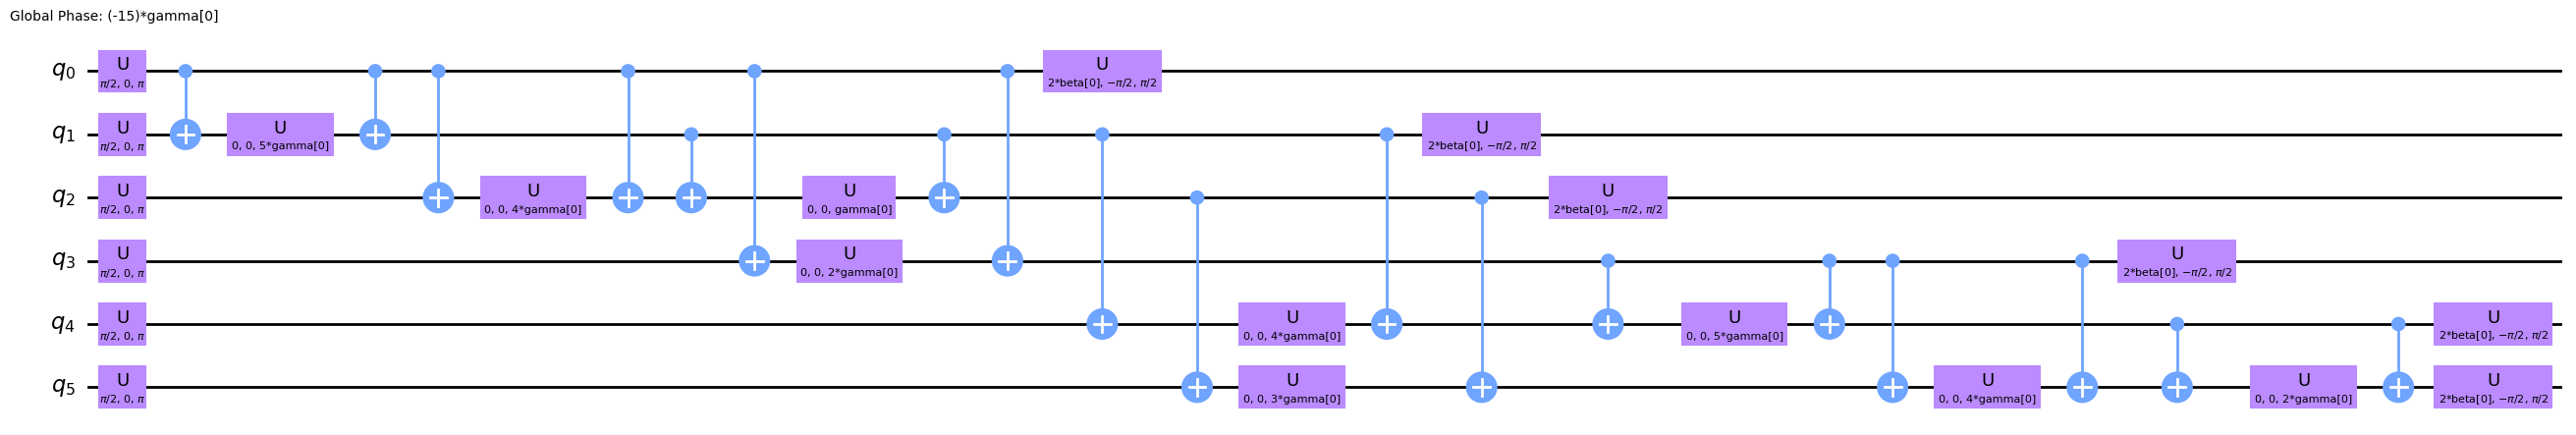

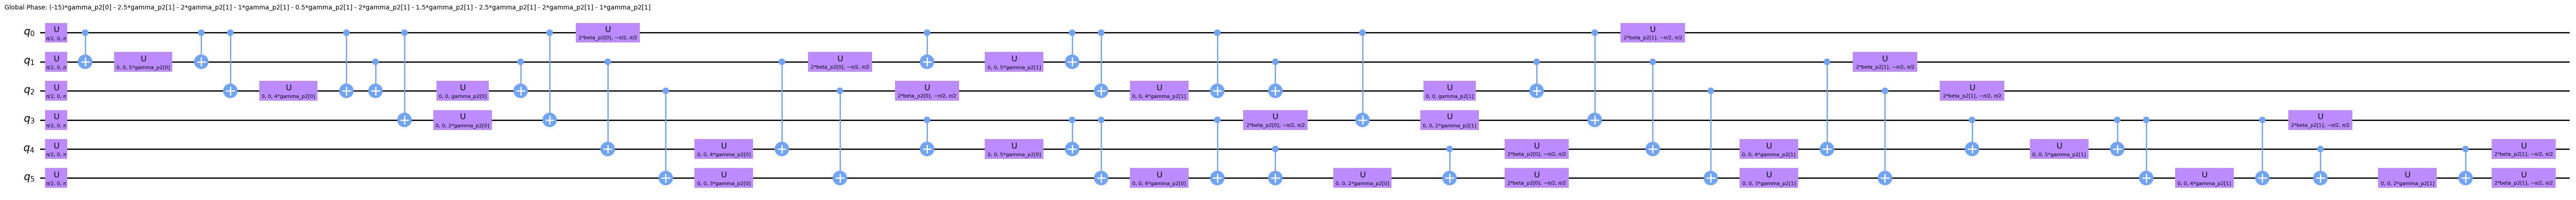


Saved:
quantum_assisted_wireless_channel_optimization/figures/01_six_ap_p1_qaoa_circuit.png
quantum_assisted_wireless_channel_optimization/figures/02_six_ap_p2_qaoa_circuit.png


In [51]:
from pathlib import Path
from IPython.display import display


# Creaing GitHub figures folder.
REPO_DIR = Path("quantum_assisted_wireless_channel_optimization")
FIGURES_DIR = REPO_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


qaoa_p1 = qaoa_circuit
# qaoa_p2 = qaoa_p2

# Decompose so the QAOA CX-RZ-CX operations are visible.
qaoa_p1_draw = qaoa_p1.decompose(reps=3)
qaoa_p2_draw = qaoa_p2.decompose(reps=3)

print("p=1 QAOA:",
      f"{qaoa_p1.num_qubits} qubits,",
      f"{qaoa_p1.count_ops().get('cx', 0)} CX gates,",
      f"depth {qaoa_p1.depth()}")

print("p=2 QAOA:",
      f"{qaoa_p2.num_qubits} qubits,",
      f"{qaoa_p2.count_ops().get('cx', 0)} CX gates,",
      f"depth {qaoa_p2.depth()}")

# Install Qiskit's optional dependency for Matplotlib circuit drawing.
try:
    import pylatexenc
except ImportError:
    print("pylatexenc not found, installing...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "pylatexenc"]
    )
    print("pylatexenc installed.")
    # Re-import after installation to make it available in the current session.
    import pylatexenc

# Draw and save p=1 circuit.
p1_figure = qaoa_p1_draw.draw(
    output="mpl",
    fold=120,
    style="clifford"
)

p1_path = FIGURES_DIR / "01_six_ap_p1_qaoa_circuit.png"

p1_figure.savefig(
    p1_path,
    dpi=300,
    bbox_inches="tight"
)

# Draw and save p=2 circuit.
p2_figure = qaoa_p2_draw.draw(
    output="mpl",
    fold=120,
    style="clifford"
)

p2_path = FIGURES_DIR / "02_six_ap_p2_qaoa_circuit.png"

p2_figure.savefig(
    p2_path,
    dpi=300,
    bbox_inches="tight"
)

display(p1_figure)
display(p2_figure)

print("\nSaved:")
print(p1_path)
print(p2_path)

Saved: quantum_assisted_wireless_channel_optimization/figures/04_six_ap_exact_milp_partition.png


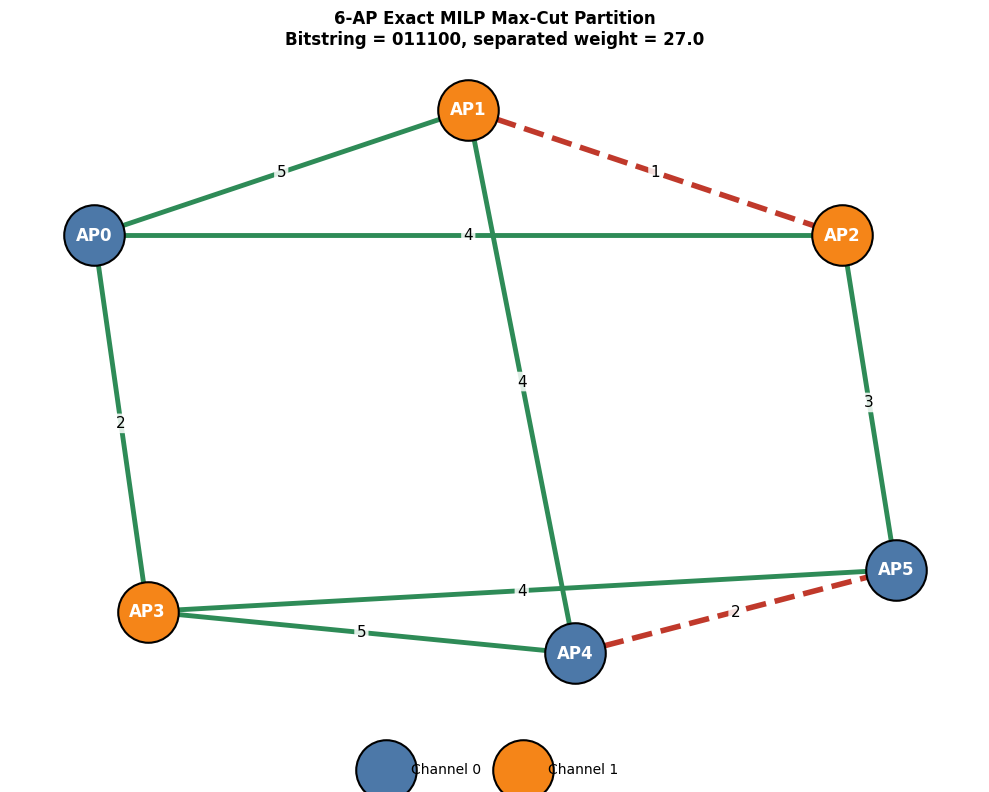

In [52]:
# Draw the exact 6-AP MILP partition

assignment = {
    ap: int(bit)
    for ap, bit in zip(AP_NODES, milp_bitstring)
}

channel_0_nodes = [
    ap
    for ap in AP_NODES
    if assignment[ap] == 0
]

channel_1_nodes = [
    ap
    for ap in AP_NODES
    if assignment[ap] == 1
]

separated_edges = [
    (ap_u, ap_v)
    for ap_u, ap_v in G.edges()
    if assignment[ap_u] != assignment[ap_v]
]

residual_edges = [
    (ap_u, ap_v)
    for ap_u, ap_v in G.edges()
    if assignment[ap_u] == assignment[ap_v]
]

fig, ax = plt.subplots(figsize=(10, 8))

# Green edges are separated by the exact Max-Cut solution
nx.draw_networkx_edges(
    G,
    positions,
    edgelist=separated_edges,
    width=3.5,
    edge_color="#2E8B57",
    style="solid",
    ax=ax
)

# Red dashed edges remain in the same channel
nx.draw_networkx_edges(
    G,
    positions,
    edgelist=residual_edges,
    width=4.0,
    edge_color="#C0392B",
    style="dashed",
    ax=ax
)

# Blue nodes use channel 0
nx.draw_networkx_nodes(
    G,
    positions,
    nodelist=channel_0_nodes,
    node_color="#4C78A8",
    node_size=1900,
    edgecolors="black",
    linewidths=1.5,
    label="Channel 0",
    ax=ax
)

# Orange nodes use channel 1
nx.draw_networkx_nodes(
    G,
    positions,
    nodelist=channel_1_nodes,
    node_color="#F58518",
    node_size=1900,
    edgecolors="black",
    linewidths=1.5,
    label="Channel 1",
    ax=ax
)

nx.draw_networkx_labels(
    G,
    positions,
    font_size=12,
    font_weight="bold",
    font_color="white",
    ax=ax
)

nx.draw_networkx_edge_labels(
    G,
    positions,
    edge_labels=edge_labels,
    font_size=11,
    rotate=False,
    bbox={
        "boxstyle": "round,pad=0.15",
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.85
    },
    ax=ax
)

plt.title(
    "6-AP Exact MILP Max-Cut Partition\n"
    f"Bitstring = {milp_bitstring}, separated weight = {milp_cut:.1f}",
    fontweight="bold"
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=2,
    frameon=False
)

plt.axis("off")
plt.tight_layout()

milp_partition_figure_path = (
    FIGURES_DIR / "04_six_ap_exact_milp_partition.png"
)

fig.savefig(
    milp_partition_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", milp_partition_figure_path)

plt.show()

### Hardware-Aware Transpilation Analysis

Just reports logical versus device constrained circuit resources, including routing overhead

Fake IBM backend (it provides backend target with coupling map, supported gates, qubit properties and calibration snapshot information) for compilation, NOT CLAIMING a real hardware execution. Qiskit transpiler uses this  for layout and routing

In [53]:
# Build the optimized 20-AP p=1 QAOA circuit

qaoa_20_circuit = build_qaoa_p1_20(
    graph=graph_qaoa_20,
    gamma=qaoa_20_gamma,
    beta=qaoa_20_beta
)

print("Qubits:", qaoa_20_circuit.num_qubits)
print("Logical CX gates:", qaoa_20_circuit.count_ops().get("cx", 0))
print("Logical depth:", qaoa_20_circuit.depth())

Qubits: 20
Logical CX gates: 158
Logical depth: 74


In [54]:
# Compile to a generic basis without hardware connectivity constraints

qaoa_20_generic = transpile(
    qaoa_20_circuit,
    basis_gates=["rz", "sx", "x", "cx"],
    optimization_level=1,
    seed_transpiler=SEED
)

print("Generic transpiled CX gates:", qaoa_20_generic.count_ops().get("cx", 0))
print("Generic transpiled depth:", qaoa_20_generic.depth())

Generic transpiled CX gates: 158
Generic transpiled depth: 80


In [55]:
from qiskit.transpiler import CouplingMap

# Create a 20-qubit heavy-hex-inspired sparse coupling map
# This is used only to study routing overhead

heavy_hex_edges = [
    (0, 1), (1, 0),
    (1, 2), (2, 1),
    (2, 3), (3, 2),
    (3, 4), (4, 3),
    (4, 5), (5, 4),
    (5, 6), (6, 5),
    (6, 7), (7, 6),
    (7, 8), (8, 7),
    (8, 9), (9, 8),

    (10, 11), (11, 10),
    (11, 12), (12, 11),
    (12, 13), (13, 12),
    (13, 14), (14, 13),
    (14, 15), (15, 14),
    (15, 16), (16, 15),
    (16, 17), (17, 16),
    (17, 18), (18, 17),
    (18, 19), (19, 18),

    (0, 10), (10, 0),
    (2, 12), (12, 2),
    (4, 14), (14, 4),
    (6, 16), (16, 6),
    (8, 18), (18, 8)
]

heavy_hex_coupling_map = CouplingMap(
    couplinglist=heavy_hex_edges
)

print("Physical qubits:", heavy_hex_coupling_map.size())
print("Allowed directed connections:", len(heavy_hex_edges))

Physical qubits: 20
Allowed directed connections: 46


In [56]:
# Transpile the 20-AP QAOA circuit onto the constrained topology

qaoa_20_routed = transpile(
    qaoa_20_circuit,
    basis_gates=["rz", "sx", "x", "cx"],
    coupling_map=heavy_hex_coupling_map,
    optimization_level=1,
    seed_transpiler=SEED
)

logical_cx = qaoa_20_circuit.count_ops().get("cx", 0)
generic_cx = qaoa_20_generic.count_ops().get("cx", 0)
routed_cx = qaoa_20_routed.count_ops().get("cx", 0)

logical_depth = qaoa_20_circuit.depth()
generic_depth = qaoa_20_generic.depth()
routed_depth = qaoa_20_routed.depth()

routing_summary = pd.DataFrame([{
    "circuit": "Logical QAOA",
    "cx_gates": logical_cx,
    "depth": logical_depth
}, {
    "circuit": "Generic transpiled",
    "cx_gates": generic_cx,
    "depth": generic_depth
}, {
    "circuit": "Heavy-hex-inspired routed",
    "cx_gates": routed_cx,
    "depth": routed_depth
}])

routing_summary["cx_overhead_vs_logical"] = (
    routing_summary["cx_gates"] / logical_cx - 1
)

routing_summary["depth_overhead_vs_logical"] = (
    routing_summary["depth"] / logical_depth - 1
)

display(
    routing_summary.style.format({
        "cx_overhead_vs_logical": "{:.2%}",
        "depth_overhead_vs_logical": "{:.2%}"
    })
)

,circuit,cx_gates,depth,cx_overhead_vs_logical,depth_overhead_vs_logical
0,Logical QAOA,158,74,0.00%,0.00%
1,Generic transpiled,158,80,0.00%,8.11%
2,Heavy-hex-inspired routed,405,262,156.33%,254.05%


The original 20-AP QAOA circuit uses 158 CX gates with depth 74. Generic transpilation keeps the same CX count and only slightly increases the depth to 80.

However, when the circuit is mapped to a heavy-hex-inspired hardware topology, the compiler must add routing operations because not all qubits are directly connected. This increases the circuit to 405 CX gates and depth 262.

This shows that limited hardware connectivity can significantly increase the cost of running QAOA. The result is a routing simulation, not an execution on real IBM hardware.



## GITHUB RELATED

In [57]:
for figure_path in sorted(FIGURES_DIR.glob("*.png")):
    print(figure_path)

quantum_assisted_wireless_channel_optimization/figures/01_six_ap_p1_qaoa_circuit.png
quantum_assisted_wireless_channel_optimization/figures/02_six_ap_p2_qaoa_circuit.png
quantum_assisted_wireless_channel_optimization/figures/04_six_ap_exact_milp_partition.png


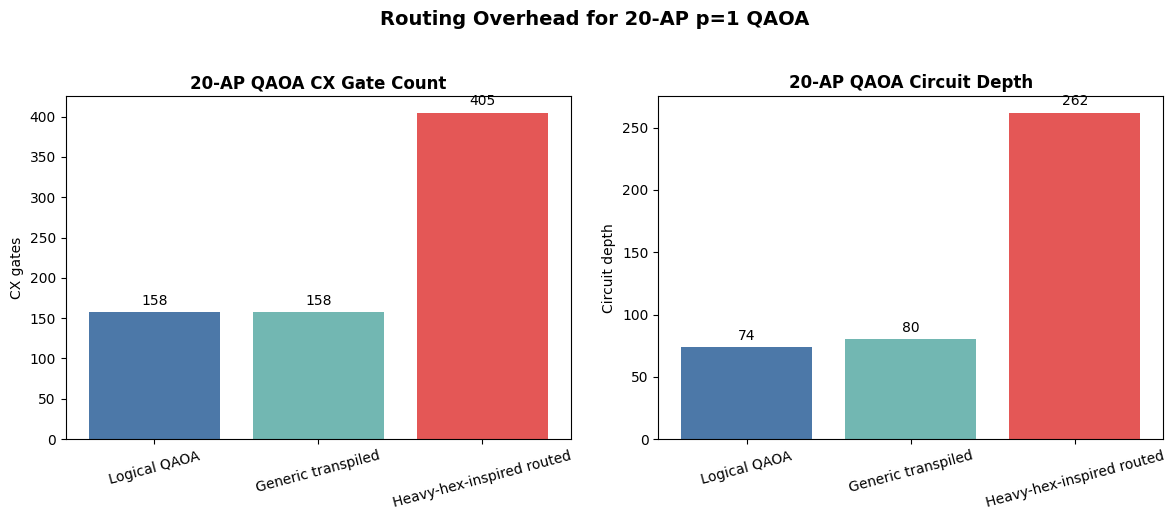

Saved routing table: quantum_assisted_wireless_channel_optimization/results/routing_overhead.csv
Saved routing figure: quantum_assisted_wireless_channel_optimization/figures/03_20ap_routing_overhead.png


In [58]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Save the routing table as a reusable CSV.
routing_summary.to_csv(
    RESULTS_DIR / "routing_overhead.csv",
    index=False
)

routing_plot = routing_summary.copy()

# Converting overhead ratios to readable percentages for a separate table if needed
routing_plot["cx_overhead_percent"] = (
    100 * routing_plot["cx_overhead_vs_logical"]
)

routing_plot["depth_overhead_percent"] = (
    100 * routing_plot["depth_overhead_vs_logical"]
)

# Build a two-panel figure: CX gate count and circuit depth
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#4C78A8", "#72B7B2", "#E45756"]

cx_bars = axes[0].bar(
    routing_plot["circuit"],
    routing_plot["cx_gates"],
    color=colors
)

axes[0].set_title("20-AP QAOA CX Gate Count", fontweight="bold")
axes[0].set_ylabel("CX gates")
axes[0].tick_params(axis="x", rotation=15)
axes[0].bar_label(cx_bars, fmt="%d", padding=3)

depth_bars = axes[1].bar(
    routing_plot["circuit"],
    routing_plot["depth"],
    color=colors
)

axes[1].set_title("20-AP QAOA Circuit Depth", fontweight="bold")
axes[1].set_ylabel("Circuit depth")
axes[1].tick_params(axis="x", rotation=15)
axes[1].bar_label(depth_bars, fmt="%d", padding=3)

fig.suptitle(
    "Routing Overhead for 20-AP p=1 QAOA",
    fontsize=14,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

routing_figure_path = FIGURES_DIR / "03_20ap_routing_overhead.png"

fig.savefig(
    routing_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved routing table:", RESULTS_DIR / "routing_overhead.csv")
print("Saved routing figure:", routing_figure_path)

### 20-QAOA Summary

In [59]:
# Export 20-AP QAOA metrics using the values computed by this notebook

qaoa20metrics_export = pd.DataFrame([{
    "n_aps": N_QUBITS_20,
    "method": "p=1 QAOA",
    "milp_optimum_cut": milp_cut_value_20,
    "statevector_expected_cut": qaoa_20_expected_cut,
    "finite_shot_expected_cut": qaoa_20_shot_expected_cut,
    "best_sample_cut": qaoa_20_shot_best_cut,
    "statevector_approximation_ratio": qaoa_20_expected_cut / milp_cut_value_20,
    "finite_shot_approximation_ratio": qaoa_20_shot_expected_cut / milp_cut_value_20,
    "best_sample_ratio": qaoa_20_shot_best_cut / milp_cut_value_20,
    "optimizer_evaluations": qaoa_20_optimization.nfev,
    "optimizer_runtime_seconds": qaoa_20_runtime_seconds,
    "shots": QAOA_20_SHOTS,
    "exact_optimum_probability": qaoa_20_optimum_probability
}])

qaoa20metrics_export.to_csv(
    RESULTS_DIR / "qaoa_20ap_metrics.csv",
    index=False
)

display(qaoa20metrics_export)
print("Saved:", RESULTS_DIR / "qaoa_20ap_metrics.csv")

,n_aps,method,milp_optimum_cut,statevector_expected_cut,finite_shot_expected_cut,best_sample_cut,statevector_approximation_ratio,finite_shot_approximation_ratio,best_sample_ratio,optimizer_evaluations,optimizer_runtime_seconds,shots,exact_optimum_probability
0,20,p=1 QAOA,0.21824,0.137535,0.137445,0.218215,0.630201,0.629788,0.999887,25,16.535779,4096,0.0


Saved: quantum_assisted_wireless_channel_optimization/results/qaoa_20ap_metrics.csv


In [60]:
# Exporting classical benchmark results computed in the notebook:
# greedy local search, simulated annealing, and exact MILP where available

classical_results = pd.concat(
    [
        greedy_results_df,
        sa_results_df,
        milp_results_10,
        milp_results_20
    ],
    ignore_index=True,
    sort=False
)

classical_results = classical_results.sort_values(
    by=["n_aps", "method"]
).reset_index(drop=True)

classical_results.to_csv(
    RESULTS_DIR / "classical_benchmark_results.csv",
    index=False
)

display(classical_results)
print("Saved:", RESULTS_DIR / "classical_benchmark_results.csv")

,n_aps,method,restarts,cut_value,runtime_seconds,group_A_size,group_B_size,runs,steps_per_run,start_temperature,end_temperature,status
0,10,Exact MILP,NaN,0.004349,0.272475,5,5,NaN,NaN,NaN,NaN,Optimal
1,10,Greedy local search,100.0,0.004349,0.056852,5,5,NaN,NaN,NaN,NaN,NaN
2,10,Simulated annealing,NaN,0.004349,1.648482,5,5,10.0,5000.0,0.003182,0.000154,NaN
3,20,Greedy local search,100.0,0.218240,0.344125,10,10,NaN,NaN,NaN,NaN,NaN
4,20,MILP,NaN,0.218240,0.990404,10,10,NaN,NaN,NaN,NaN,Optimal
5,20,Simulated annealing,NaN,0.218215,2.835413,10,10,10.0,5000.0,0.013533,0.000656,NaN
6,40,Greedy local search,100.0,1.122507,4.572850,18,22,NaN,NaN,NaN,NaN,NaN
7,40,Simulated annealing,NaN,1.117967,10.575170,19,21,10.0,5000.0,0.138113,0.006692,NaN


Saved: quantum_assisted_wireless_channel_optimization/results/classical_benchmark_results.csv


In [61]:
# Export the 6-AP verification and QAOA benchmark using current snake_case variables

six_ap_benchmark = pd.DataFrame([
    {
        "n_aps": N,
        "setting": "exact_enumeration_milp",
        "expected_cut": exact_optimum,
        "approximation_ratio": 1.0,
        "optimal_state_probability": np.nan,
        "cx_gates": 0,
        "circuit_depth": 0,
        "noise_model": "none"
    },
    {
        "n_aps": N,
        "setting": "qaoa_p1_ideal",
        "expected_cut": best_p1["expected_cut"],
        "approximation_ratio": best_p1["expected_cut"] / exact_optimum,
        "optimal_state_probability": p1_optimum_probability,
        "cx_gates": qaoa_circuit.count_ops().get("cx", 0),
        "circuit_depth": qaoa_circuit.depth(),
        "noise_model": "none"
    },
    {
        "n_aps": N,
        "setting": "qaoa_p1_noisy",
        "expected_cut": p1_noisy_expected_cut,
        "approximation_ratio": p1_noisy_expected_cut / exact_optimum,
        "optimal_state_probability": p1_noisy_optimum_probability,
        "cx_gates": qaoa_circuit.count_ops().get("cx", 0),
        "circuit_depth": qaoa_circuit.depth(),
        "noise_model": "cx_depolarizing_0.01__readout_flip_0.015"
    },
    {
        "n_aps": N,
        "setting": "qaoa_p2_ideal",
        "expected_cut": best_p2["expected_cut"],
        "approximation_ratio": best_p2["expected_cut"] / exact_optimum,
        "optimal_state_probability": p2_shot_optimum_probability,
        "cx_gates": qaoa_p2.count_ops().get("cx", 0),
        "circuit_depth": qaoa_p2.depth(),
        "noise_model": "none"
    },
    {
        "n_aps": N,
        "setting": "qaoa_p2_noisy",
        "expected_cut": p2_noisy_expected_cut,
        "approximation_ratio": p2_noisy_expected_cut / exact_optimum,
        "optimal_state_probability": p2_noisy_optimum_probability,
        "cx_gates": qaoa_p2.count_ops().get("cx", 0),
        "circuit_depth": qaoa_p2.depth(),
        "noise_model": "cx_depolarizing_0.01__readout_flip_0.015"
    }
])

six_ap_benchmark.to_csv(
    RESULTS_DIR / "six_ap_qaoa_benchmark.csv",
    index=False
)

display(
    six_ap_benchmark.style.format({
        "expected_cut": "{:.6f}",
        "approximation_ratio": "{:.2%}",
        "optimal_state_probability": "{:.2%}"
    })
)

print("Saved:", RESULTS_DIR / "six_ap_qaoa_benchmark.csv")

,n_aps,setting,expected_cut,approximation_ratio,optimal_state_probability,cx_gates,circuit_depth,noise_model
0,6,exact_enumeration_milp,27.000000,100.00%,nan%,0,0,none
1,6,qaoa_p1_ideal,20.614142,76.35%,21.17%,18,23,none
2,6,qaoa_p1_noisy,19.818848,73.40%,17.70%,18,23,cx_depolarizing_0.01__readout_flip_0.015
3,6,qaoa_p2_ideal,20.805679,77.06%,28.64%,36,36,none
4,6,qaoa_p2_noisy,20.064209,74.31%,20.97%,36,36,cx_depolarizing_0.01__readout_flip_0.015


Saved: quantum_assisted_wireless_channel_optimization/results/six_ap_qaoa_benchmark.csv


In [62]:
print("\nRESULTS")
for file_path in sorted(RESULTS_DIR.glob("*")):
    print(" -", file_path.name)

print("FIGURES")
for file_path in sorted(FIGURES_DIR.glob("*")):
    print(" -", file_path.name)


RESULTS
 - classical_benchmark_results.csv
 - qaoa_20ap_metrics.csv
 - routing_overhead.csv
 - six_ap_qaoa_benchmark.csv
FIGURES
 - 01_six_ap_p1_qaoa_circuit.png
 - 02_six_ap_p2_qaoa_circuit.png
 - 03_20ap_routing_overhead.png
 - 04_six_ap_exact_milp_partition.png


### README

In [63]:
# Create README.md for the final GitHub repository

readme_text = r"""# Quantum-Assisted Wireless Channel Assignment Optimization
## MILP, Heuristic and (noisy) QAOA Benchmarking for Two-Channel Interference Management

**Author:** Praneshraj Tiruppur Nagarajan Dhyaneswar
**Date:** October 1, 2026
**Project type:** Reproducible classical and quantum optimization benchmark

This project studies two-channel wireless access-point (AP) assignment as a
weighted MaxCut optimization problem. It compares exact classical optimization,
heuristics and Quantum Approximate Optimization Algorithm (QAOA) simulations.

It does not claim quantum advantage.

## Problem statement

Given AP positions and a symmetric interference-proxy graph, assign each AP to
one of two orthogonal channels to minimize retained same-channel interference.
Equivalently, maximize the total edge weight separated by the assignment:
a weighted MaxCut problem.

The project compares proven-optimal MILP solutions, weighted greedy local search,
simulated annealing and QAOA.

The six-node graph is an exact verification kernel. Synthetic propagation graphs
with N=10, 20, and 40 APs are used for classical scaling experiments. A
resource-limited p=1 QAOA simulation is evaluated for the 20-AP graph.

## Scope and honest limitations

- This is FFR-inspired two-channel allocation, not a complete FFR, SINR, or
  throughput model.
- AP-to-AP received power is an interference proxy; there are no UE receivers,
  traffic demands, wall models, or scheduling effects.
- The legacy 2 GHz urban-macro expression is not validated for short-range Wi-Fi.
- Shadowing is reciprocal and independent across links; it is not spatially correlated.
- Thresholding may discard low-power links whose aggregate interference could matter.
- The noise model is synthetic and is not calibrated to a specific quantum processor.
- A noisy depth inversion is an experimental hypothesis, not a required outcome.
- The heavy-hex-inspired result is a routing study, not execution on real hardware.

## Energy convention

For binary channel assignments \(x_u \in \{0,1\}\), the weighted cut value is:

\[
C(x) =
\sum_{(u,v)\in E} w_{uv}
\left[x_u + x_v - 2x_u x_v\right]
\]

The upper-triangular QUBO matrix is constructed such that:

\[
x^TQx = -C(x)
\]

The Ising energy Hamiltonian is:

\[
H_{\mathrm{energy}} =
\sum_{(u,v)\in E}
\frac{w_{uv}}{2}
\left(Z_uZ_v-I\right)
\]

For each computational-basis assignment:

\[
H_{\mathrm{energy}}(x) = -C(x)
\]

Therefore, minimizing \(H_{\mathrm{energy}}\) is equivalent to maximizing the
weighted cut.

Project bitstrings use `AP0` through `AP(N-1)`. Qiskit measurement strings are
reversed before scoring so that bit \(i\) corresponds to AP \(i\).

## Main results

### Six-AP verification benchmark

| Setting | Expected cut | Approximation ratio | Optimal-state probability | CX gates | Circuit depth |
|---|---:|---:|---:|---:|---:|
| Exact enumeration / MILP | 27.000000 | 100.00% | — | 0 | 0 |
| QAOA p=1, ideal | 20.614142 | 76.35% | 21.17% | 18 | 23 |
| QAOA p=1, noisy | 19.818848 | 73.40% | 17.70% | 18 | 23 |
| QAOA p=2, ideal | 20.805679 | 77.06% | 28.64% | 36 | 36 |
| QAOA p=2, noisy | 20.064209 | 74.31% | 20.97% | 36 | 36 |

The 6-AP graph verifies the full optimization workflow: exhaustive enumeration,
MILP, QUBO, Ising encoding, ideal QAOA, finite-shot sampling, and synthetic noise.

The selected p=2 multistart result improves on p=1 but uses twice as many CX gates.

### Classical scaling benchmark

| APs | Exact MILP cut | Greedy cut | Simulated annealing cut |
|---:|---:|---:|---:|
| 10 | 0.004349 | 0.004349 | 0.004349 |
| 20 | 0.218240 | 0.218240 | 0.218215 |
| 40 | — | 1.122507 | 1.117967 |

For 10 APs, both heuristics matched the exact MILP result. For 20 APs, greedy
local search matched the exact MILP optimum and simulated annealing reached
99.99% of that optimum. At 40 APs, greedy local search slightly outperformed
the selected simulated-annealing configuration.

### 20-AP QAOA benchmark

| Metric | Value |
|---|---:|
| Active interference edges | 79 |
| Exact MILP optimum | 0.218240 |
| p=1 statevector expected cut | 0.137535 |
| Statevector approximation ratio | 63.02% |
| Finite-shot expected cut | 0.137445 |
| Best sampled cut | 0.218215 |
| Best-sample ratio | 99.99% |
| COBYLA evaluations | 25 |
| Optimizer runtime | 17.13 seconds |
| Measurement shots | 4,096 |
| Exact-optimum sampling probability | 0.0000 |

The 20-AP QAOA experiment is intentionally resource-limited. It uses p=1, a
limited COBYLA budget, and statevector simulation. Its expected cut reaches
63.02% of the exact MILP optimum. The best measured sample is near-optimal,
but the recorded exact-optimum sampling probability is zero.

### Hardware-aware routing analysis

| Circuit | CX gates | Depth | CX overhead | Depth overhead |
|---|---:|---:|---:|---:|
| Logical QAOA | 158 | 74 | 0.00% | 0.00% |
| Generic transpiled | 158 | 80 | 0.00% | 8.11% |
| Heavy-hex-inspired routed | 405 | 262 | 156.33% | 254.05% |

Generic transpilation preserves the 158-CX logical gate count and only increases
depth from 74 to 80. Under the synthetic heavy-hex-inspired coupling map, routing
increases the circuit to 405 CX gates and depth 262. This is a topology-level
routing study, not execution on IBM hardware.

## Figures

### Exact 6-AP MILP partition

![Exact 6-AP MILP partition](figures/04_six_ap_exact_milp_partition.png)

The two node colours represent the two channels. Green edges are separated by
the exact MaxCut partition; red dashed edges remain within the same channel.

### Six-AP QAOA circuits

| p=1 circuit | p=2 circuit |
|---|---|
| ![Six-AP p=1 QAOA circuit](figures/01_six_ap_p1_qaoa_circuit.png) | ![Six-AP p=2 QAOA circuit](figures/02_six_ap_p2_qaoa_circuit.png) |

### 20-AP routing overhead

![20-AP routing overhead](figures/03_20ap_routing_overhead.png)

## Repository structure

```text
quantum_assisted_wireless_channel_optimization/
├── notebooks/   Final reproducible Jupyter notebook
├── figures/     Exported figures used in this README
├── results/     CSV files with benchmark outputs
├── README.md
├── requirements.txt
├── .gitignore
└── LICENSE
```

## Run locally

```bash
git clone [https://github.com/](https://github.com/)<your-github-username>/quantum_assisted_wireless_channel_optimization.git
cd quantum_assisted_wireless_channel_optimization

python -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt

jupyter notebook
```

Open the final notebook from the `notebooks/` folder.

## Tech

Python · NumPy · pandas · SciPy · NetworkX · PuLP/HiGHS · Qiskit · Qiskit Aer · Matplotlib
"""

readme_path = REPO_DIR / "README.md"

readme_path.write_text(
    readme_text,
    encoding="utf-8"
)

print("README created:", readme_path)
print("Size:", readme_path.stat().st_size, "bytes")

README created: quantum_assisted_wireless_channel_optimization/README.md
Size: 6631 bytes


In [68]:
# from getpass import getpass
# from urllib.parse import quote


# github_username = "Jahprance"
# github_token = getpass("Paste your GitHub Personal Access Token: ")

# push_url = (
#     f"https://{github_username}:{quote(github_token, safe='')}"
#     "@github.com/Jahprance/quantum_assisted_wireless_channel_optimization.git"
# )

# result = subprocess.run(
#     ["git", "push", "-u", push_url, "main"],
#     cwd=REPO_DIR,
#     text=True,
#     capture_output=True
# )

# print(result.stdout)
# print(result.stderr)

# if result.returncode == 0:
#     print("Push complete. Refresh your GitHub repository page.")
# else:
#     print("Push failed. Check the error message above.")

In [69]:
import subprocess

subprocess.run(
    [
        "git",
        "remote",
        "set-url",
        "origin",
        "https://github.com/Jahprance/quantum_assisted_wireless_channel_optimization.git"
    ],
    cwd=REPO_DIR,
    check=True
)

print("Git remote cleaned.")

Git remote cleaned.
